# 하남 교산 안전 시설물 입지 선정

이 노트북은 하남 교산 지역의 안전 시설물(CCTV, 비상벨 등) 최적 입지를 선정합니다.

처리 과정:
1. 격자, 토지이용, 우선순위 데이터셋 로드
2. 토지이용 + 도로 격자 기준으로 설치 가능 후보지 생성
3. 위험 지표 및 미성년자 유동 추정 지표로부터 수요 가중치 생성
4. 예산 시나리오(k=10/20/30)에 대한 탐욕적 최대 커버리지 선정 실행
5. 시나리오 요약 및 선정된 부지 내보내기

필수 맵 출력:
- `hanam_gyosan_selected_sites_k20.png`
- `hanam_gyosan_selected_sites_k_scenarios.png`

In [1]:
import os
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic' if os.name == 'nt' else 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False


In [2]:
SCORE_COL = '\uc6b0\uc120\uc21c\uc704_\uc810\uc218'
RANK_COL = '\uc6b0\uc120\uc21c\uc704_\uc21c\uc704'
FLOW_COL = '\ubbf8\uc131\ub144\uc790_\uc720\ub3d9_\ucd94\uc815'
ROAD_COL = '\ub3c4\ub85c_\uaca9\uc790_\uc5ec\ubd80'


In [3]:
def find_data_dir():
    roots = [Path.cwd(), *Path.cwd().parents]
    candidates = []

    for root in roots:
        candidates.append(root / 'data')
        for child in root.iterdir():
            if child.is_dir():
                candidates.append(child / 'data')

    checked = set()
    for cand in candidates:
        try:
            c = cand.resolve()
        except Exception:
            continue

        if c in checked or (not c.exists()):
            continue
        checked.add(c)

        has_grid = len(list(c.rglob('02._*.geojson'))) > 0
        has_land = len(list(c.rglob('23._*.geojson'))) > 0
        if has_grid and has_land:
            return c

    raise FileNotFoundError('Could not locate a valid data directory (needs 02._*.geojson and 23._*.geojson).')


data_dir = find_data_dir()
print('data_dir:', data_dir)


data_dir: C:\Users\a0109\.jupyter\1최종_LH\data


In [4]:
grid_path = sorted(data_dir.rglob('02._*.geojson'))[0]
landuse_path = sorted(data_dir.rglob('23._*.geojson'))[0]


def read_csv_fallback(path, nrows=None):
    for enc in ('utf-8', 'utf-8-sig', 'cp949'):
        try:
            return pd.read_csv(path, encoding=enc, nrows=nrows)
        except Exception:
            pass
    raise ValueError(f'CSV read failed: {path}')


required_cols = {'gid', SCORE_COL, FLOW_COL, ROAD_COL}

# Prefer original priority tables, not generated output tables
preferred_patterns = [
    '*하남교산*설치우선순위*격자*.csv',
    '*설치우선순위*격자*.csv',
]
exclude_keywords = ['selected', 'combined', 'scenario', 'summary', 'analysis', 'facility_split']

candidate_csvs = []
for pat in preferred_patterns:
    candidate_csvs.extend(sorted(data_dir.rglob(pat)))

# fallback: scan all csvs if preferred pattern fails
if not candidate_csvs:
    candidate_csvs = sorted(data_dir.rglob('*.csv'))

valid = []
for p in candidate_csvs:
    name_l = p.name.lower()
    if any(k in name_l for k in exclude_keywords):
        continue

    try:
        probe = read_csv_fallback(p, nrows=5)
        if required_cols.issubset(set(probe.columns)):
            # row count score: prioritize richer source tables
            try:
                full = read_csv_fallback(p)
                n = len(full)
            except Exception:
                n = -1
            valid.append((n, p))
    except Exception:
        continue

if not valid:
    raise FileNotFoundError('Priority CSV with required columns was not found.')

# choose largest matching table
priority_path = sorted(valid, key=lambda x: x[0], reverse=True)[0][1]
output_dir = priority_path.parent

print('grid_path    :', grid_path)
print('landuse_path :', landuse_path)
print('priority_path:', priority_path)
print('priority_rows:', sorted(valid, key=lambda x: x[0], reverse=True)[0][0])
print('output_dir   :', output_dir)


grid_path    : C:\Users\a0109\.jupyter\1최종_LH\data\격자_데이터\02._격자_(하남교산).geojson
landuse_path : C:\Users\a0109\.jupyter\1최종_LH\data\토지_데이터\23._토지이용계획도_(하남교산).geojson
priority_path: C:\Users\a0109\.jupyter\1최종_LH\data\통합_데이터\하남교산_설치우선순위_격자.csv
priority_rows: 770
output_dir   : C:\Users\a0109\.jupyter\1최종_LH\data\통합_데이터


In [5]:
grid = gpd.read_file(grid_path)
landuse = gpd.read_file(landuse_path)
priority = read_csv_fallback(priority_path)

print('grid rows   :', len(grid))
print('landuse rows:', len(landuse))
print('priority rows:', len(priority))
print('grid cols   :', list(grid.columns))
print('landuse cols:', list(landuse.columns))
print('priority cols:', list(priority.columns))


grid rows   : 770
landuse rows: 761
priority rows: 770
grid cols   : ['gbn', 'gid', 'geometry']
landuse cols: ['zoneCode', 'zoneName', 'blockName', 'blockType', 'geometry']
priority cols: ['gid', '유사_4시구_gid', '유사도', '유사_고위험_여부', '도로_비율', '주거_비율', '상업_비율', '학교_비율', '녹지_비율', '도로_격자_여부', '우선순위_점수', '우선순위_순위', '미성년자_유동_추정']


In [6]:
if 'gid' not in grid.columns or 'gid' not in priority.columns:
    raise KeyError('Both grid and priority datasets need gid column.')

gdf = grid.merge(priority, on='gid', how='left')

for c in [SCORE_COL, RANK_COL, FLOW_COL, ROAD_COL]:
    if c in gdf.columns:
        gdf[c] = pd.to_numeric(gdf[c], errors='coerce').fillna(0)

metric_crs = 'EPSG:5179'
gdf_m = gdf.to_crs(metric_crs)
landuse_m = landuse.to_crs(metric_crs)

print('merged rows:', len(gdf_m))
print('metric CRS:', gdf_m.crs)


merged rows: 770
metric CRS: EPSG:5179


In [7]:
# 격자별 주요 토지이용 결정 (최대 교차 면적 기준, 재실행에 강건함)
# 1) 토지이용 유형 컬럼명 안전하게 해결
landuse_type_col = None
for cand in ['blockType', 'blocktype', 'BLOCKTYPE']:
    if cand in landuse_m.columns:
        landuse_type_col = cand
        break

if landuse_type_col is None:
    fuzzy = [c for c in landuse_m.columns if ('block' in c.lower() and 'type' in c.lower())]
    if fuzzy:
        landuse_type_col = fuzzy[0]

if landuse_type_col is None:
    raise KeyError(f"No block-type column found in landuse_m. columns={list(landuse_m.columns)}")

# 2) 재실행 시 중복 접미사 문제 방지 (blockType_x / blockType_y)
gdf_m = gdf_m.drop(columns=['blockType', 'inter_area_m2'], errors='ignore')

# 3) 오버레이 연산 수행
landuse_for_overlay = landuse_m[[landuse_type_col, 'geometry']].rename(columns={landuse_type_col: 'blockType'})
overlay = gpd.overlay(
    gdf_m[['gid', 'geometry']],
    landuse_for_overlay,
    how='intersection',
    keep_geom_type=False,
)

# 4) 최대 교차 면적 기준으로 주요 토지이용 유형 결정
if overlay.empty:
    gdf_m['blockType'] = pd.NA
else:
    overlay['inter_area_m2'] = overlay.geometry.area

    dominant = (
        overlay.groupby(['gid', 'blockType'], as_index=False)['inter_area_m2'].sum()
        .sort_values(['gid', 'inter_area_m2'], ascending=[True, False])
        .drop_duplicates('gid')
        [['gid', 'blockType']]
    )

    gdf_m = gdf_m.merge(dominant, on='gid', how='left', validate='one_to_one')

print('주요 토지이용 매칭 결과:', gdf_m['blockType'].notna().sum(), '/', len(gdf_m))
print(gdf_m['blockType'].fillna('NA').value_counts().head(15))

주요 토지이용 매칭 결과: 770 / 770
blockType
공동주택        171
공원          140
도로          100
자족기능확보시설     87
경관녹지         86
교육시설         28
복합시설용지기타     27
하천           26
주상복합         23
단독주택         21
완충녹지         17
유수지           9
근린생활시설용지      5
공공공지          4
종합의료시설        4
Name: count, dtype: int64


In [8]:
# 안전 시설물 설치 가능 키워드 정의 (도로, 공원, 녹지 등)
installable_keywords = [
    '\ub3c4\ub85c', '\ubcf4\ud589', '\uacf5\uc6d0', '\ub179\uc9c0', '\uacf5\uc9c0',
    '\ud558\ucc9c', '\uad11\uc7a5', '\uc8fc\ucc28\uc7a5', '\uad50\uc721', '\ud559\uad50',
    '\uacf5\uacf5', '\ubcf5\uc9c0', '\ubb38\ud654', '\uc0c1\uc5c5', '\uadfc\ub9b0\uc0dd\ud65c'
]
pattern = '|'.join(installable_keywords)

# 토지이용 기반 설치 가능 여부 판단
gdf_m['installable_by_landuse'] = gdf_m['blockType'].fillna('').str.contains(pattern, regex=True)
# 도로 격자 여부 또는 토지이용 설치 가능 여부로 후보지 선정
gdf_m['is_candidate'] = (gdf_m[ROAD_COL] > 0) | gdf_m['installable_by_landuse']

cand = gdf_m[gdf_m['is_candidate']].copy()

print('전체 격자 수:', len(gdf_m))
print('후보 격자 수:', len(cand), f'({len(cand)/len(gdf_m)*100:.1f}%)')
print('후보지 토지이용 유형 분포:')
print(cand['blockType'].fillna('NA').value_counts().head(15))

전체 격자 수: 770
후보 격자 수: 657 (85.3%)
후보지 토지이용 유형 분포:
blockType
공원          140
공동주택        104
도로          100
경관녹지         86
자족기능확보시설     68
교육시설         28
하천           26
단독주택         20
복합시설용지기타     19
완충녹지         17
주상복합         16
근린생활시설용지      5
복합용지          4
공공공지          4
종합의료시설        3
Name: count, dtype: int64


count    770.000000
mean       0.363746
std        0.235521
min        0.024809
25%        0.143787
50%        0.296477
75%        0.651884
max        0.861806
Name: demand_weight, dtype: float64


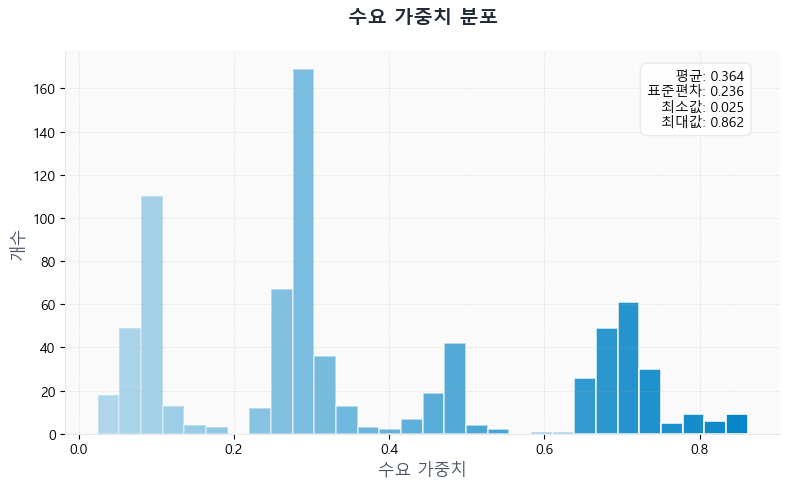

In [9]:
def minmax(s):
    s = pd.to_numeric(s, errors='coerce').fillna(0)
    lo, hi = s.min(), s.max()
    return (s - lo) / (hi - lo + 1e-9)

if SCORE_COL not in gdf_m.columns or FLOW_COL not in gdf_m.columns:
    raise KeyError('Required score columns are missing.')

# 수요 가중치 계산 (위험 점수 70% + 미성년자 유동 추정 30%)
gdf_m['demand_weight'] = 0.7 * minmax(gdf_m[SCORE_COL]) + 0.3 * minmax(gdf_m[FLOW_COL])

print(gdf_m['demand_weight'].describe())

#  고급화된 수요 가중치 분포 시각화
fig, ax = plt.subplots(figsize=(8, 5), dpi=100)
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#fafafa')

# 히스토그램 스타일 개선
n, bins, patches = ax.hist(
    gdf_m['demand_weight'], 
    bins=30, 
    color='#0284c7', 
    alpha=0.85,
    edgecolor='#ffffff',
    linewidth=1.2
)

# 그라데이션 효과 추가
for i, patch in enumerate(patches):
    patch.set_alpha(0.3 + (i / len(patches)) * 0.7)

# 제목과 축 스타일 개선
ax.set_title(
    '수요 가중치 분포', 
    fontsize=14, 
    fontweight='bold', 
    color='#1f2937',
    pad=20
)
ax.set_xlabel('수요 가중치', fontsize=12, color='#4b5563')
ax.set_ylabel('개수', fontsize=12, color='#4b5563')

# 그리드 스타일 개선
ax.grid(alpha=0.3, linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#e5e7eb')
ax.spines['bottom'].set_color('#e5e7eb')

# 통계 정보 추가
stats_text = (
    f'평균: {gdf_m["demand_weight"].mean():.3f}\n'
    f'표준편차: {gdf_m["demand_weight"].std():.3f}\n'
    f'최소값: {gdf_m["demand_weight"].min():.3f}\n'
    f'최대값: {gdf_m["demand_weight"].max():.3f}'
)

ax.text(
    0.95, 0.95, stats_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#e5e7eb'),
    zorder=10
)

plt.tight_layout()
plt.show()

In [10]:
def greedy_max_coverage(demand_xy, cand_xy, weights, radius_m=250.0, k=20):
    """
    탐욕적 최대 커버리지 알고리즘
    수요 지점을 최대한 커버하도록 k개의 시설물 입지를 선택
    
    Parameters:
    - demand_xy: 수요 지점 좌표 배열
    - cand_xy: 후보지 좌표 배열  
    - weights: 수요 가중치 배열
    - radius_m: 커버리지 반경 (미터)
    - k: 선택할 시설물 수
    """
    # 모든 수요-후보지 쌍 간의 거리 제곱 계산
    d2 = ((demand_xy[:, None, :] - cand_xy[None, :, :]) ** 2).sum(axis=2)
    # 반경 내 커버리지 여부 행렬
    cover = d2 <= (radius_m ** 2)

    selected = []  # 선택된 후보지 인덱스
    covered = np.zeros(len(demand_xy), dtype=bool)  # 커버된 수요 지점
    gains = []  # 각 선택 시 증가 커버리지

    # 최대 k개 또는 가능한 후보지 수만큼 반복
    for _ in range(min(k, cand_xy.shape[0])):
        # 각 후보지의 기대 이득 계산 (아직 커버되지 않은 수요 × 커버리지 × 가중치)
        gain = ((~covered)[:, None] * cover * weights[:, None]).sum(axis=0)
        # 이미 선택된 후보지는 제외
        if selected:
            gain[np.array(selected, dtype=int)] = -1

        # 최대 이득을 갖는 후보지 선택
        j = int(np.argmax(gain))
        best_gain = float(gain[j])
        if best_gain <= 0:
            break

        selected.append(j)
        covered = covered | cover[:, j]
        gains.append(best_gain)

    return selected, covered, gains


def nearest_distance_to_selected(demand_xy, sel_xy):
    """
    각 수요 지점에서 선택된 시설물까지의 최단 거리 계산
    """
    if len(sel_xy) == 0:
        return np.full(len(demand_xy), np.nan)
    d2 = ((demand_xy[:, None, :] - sel_xy[None, :, :]) ** 2).sum(axis=2)
    return np.sqrt(d2.min(axis=1))

In [11]:
# 시나리오 분석 설정 (k=10, 20, 30개 시설물)
scenario_ks = [10, 20, 30]
radius_m = 250.0  # 커버리지 반경 250m

demand_df = gdf_m.copy()
cand_df = cand.copy()

# 수요 지점 및 후보지 좌표 배열 생성
demand_xy = np.column_stack([demand_df.geometry.centroid.x.values, demand_df.geometry.centroid.y.values])
cand_xy = np.column_stack([cand_df.geometry.centroid.x.values, cand_df.geometry.centroid.y.values])
weights = demand_df['demand_weight'].values

# 각 시나리오별 최적 입지 선정 실행
scenario_rows = []
scenario_selected = {}

for k in scenario_ks:
    # 탐욕적 최대 커버리지 알고리즘 실행
    sel_idx, covered, gains = greedy_max_coverage(demand_xy, cand_xy, weights, radius_m=radius_m, k=k)

    # 성능 지표 계산
    sel_xy = cand_xy[sel_idx] if len(sel_idx) else np.empty((0, 2))
    nearest_m = nearest_distance_to_selected(demand_xy, sel_xy)

    # 시나리오 결과 저장
    scenario_rows.append({
        'k': k,
        'radius_m': radius_m,
        'selected_count': len(sel_idx),
        'coverage_ratio': float(covered.mean()),  # 면적 커버리지 비율
        'weighted_coverage_ratio': float(weights[covered].sum() / (weights.sum() + 1e-9)),  # 가중치 커버리지 비율
        'mean_nearest_distance_m': float(np.nanmean(nearest_m)) if len(sel_idx) else np.nan,  # 평균 최단 거리
    })

    scenario_selected[k] = {
        'sel_idx': sel_idx,
        'covered': covered,
        'gains': gains,
    }

# 시나리오 요약 테이블 생성
scenario_summary = pd.DataFrame(scenario_rows).sort_values('k').reset_index(drop=True)
scenario_summary

,k,radius_m,selected_count,coverage_ratio,weighted_coverage_ratio,mean_nearest_distance_m
0,10,250.0,10,0.263636,0.407568,455.389074
1,20,250.0,20,0.509091,0.652752,277.860552
2,30,250.0,30,0.722078,0.821615,213.100975


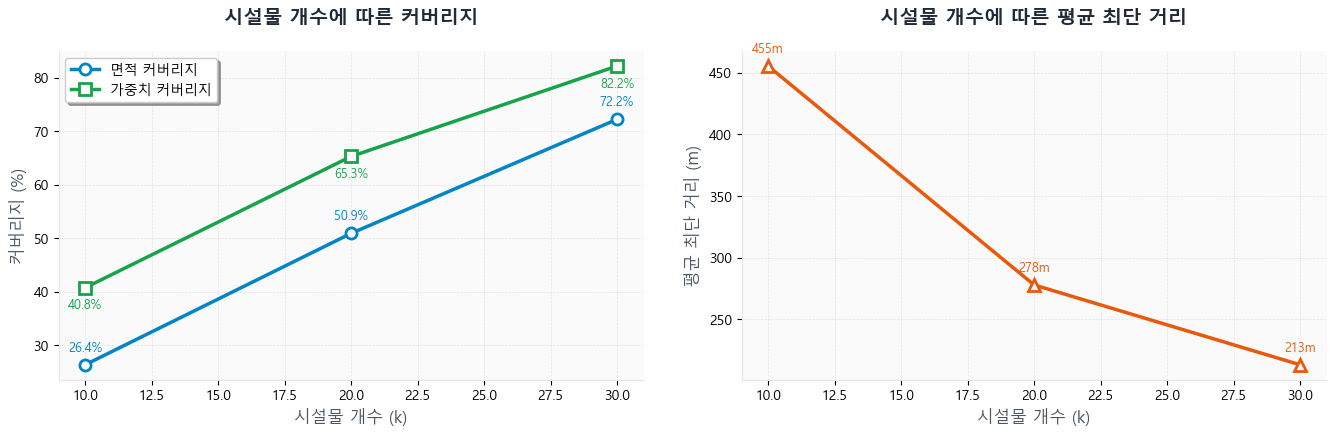

In [12]:
#  고급화된 시나리오별 커버리지 및 거리 분석 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)
fig.patch.set_facecolor('#ffffff')

# 색상 팔레트 설정
colors_coverage = ['#0284c7', '#16a34a', '#7c3aed']
colors_distance = ['#ea580c', '#dc2626', '#f59e0b']

# 왼쪽: 시설물 개수에 따른 커버리지 비율
ax1 = axes[0]
ax1.set_facecolor('#fafafa')

# 면적 커버리지
ax1.plot(
    scenario_summary['k'], 
    scenario_summary['coverage_ratio'] * 100, 
    marker='o', 
    color=colors_coverage[0],
    linewidth=2.5,
    markersize=8,
    markerfacecolor='white',
    markeredgewidth=2,
    label='면적 커버리지'
)

# 가중치 커버리지
ax1.plot(
    scenario_summary['k'], 
    scenario_summary['weighted_coverage_ratio'] * 100, 
    marker='s', 
    color=colors_coverage[1],
    linewidth=2.5,
    markersize=8,
    markerfacecolor='white',
    markeredgewidth=2,
    label='가중치 커버리지'
)

# 데이터 포인트에 값 표시
for i, (_, row) in enumerate(scenario_summary.iterrows()):
    ax1.annotate(
        f'{row["coverage_ratio"]*100:.1f}%',
        (row['k'], row['coverage_ratio']*100),
        textcoords="offset points",
        xytext=(0,10),
        ha='center',
        fontsize=9,
        color=colors_coverage[0]
    )
    ax1.annotate(
        f'{row["weighted_coverage_ratio"]*100:.1f}%',
        (row['k'], row['weighted_coverage_ratio']*100),
        textcoords="offset points",
        xytext=(0,-15),
        ha='center',
        fontsize=9,
        color=colors_coverage[1]
    )

ax1.set_title(
    '시설물 개수에 따른 커버리지', 
    fontsize=14, 
    fontweight='bold', 
    color='#1f2937',
    pad=20
)
ax1.set_xlabel('시설물 개수 (k)', fontsize=12, color='#4b5563')
ax1.set_ylabel('커버리지 (%)', fontsize=12, color='#4b5563')
ax1.legend(
    loc='upper left',
    frameon=True,
    fancybox=True,
    shadow=True,
    fontsize=10
)
ax1.grid(alpha=0.3, linestyle='--', linewidth=0.5)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#e5e7eb')
ax1.spines['bottom'].set_color('#e5e7eb')

# 오른쪽: 시설물 개수에 따른 평균 최단 거리
ax2 = axes[1]
ax2.set_facecolor('#fafafa')

ax2.plot(
    scenario_summary['k'], 
    scenario_summary['mean_nearest_distance_m'], 
    marker='^', 
    color=colors_distance[0],
    linewidth=2.5,
    markersize=8,
    markerfacecolor='white',
    markeredgewidth=2
)

# 데이터 포인트에 값 표시
for i, (_, row) in enumerate(scenario_summary.iterrows()):
    ax2.annotate(
        f'{row["mean_nearest_distance_m"]:.0f}m',
        (row['k'], row['mean_nearest_distance_m']),
        textcoords="offset points",
        xytext=(0,10),
        ha='center',
        fontsize=9,
        color=colors_distance[0]
    )

ax2.set_title(
    '시설물 개수에 따른 평균 최단 거리', 
    fontsize=14, 
    fontweight='bold', 
    color='#1f2937',
    pad=20
)
ax2.set_xlabel('시설물 개수 (k)', fontsize=12, color='#4b5563')
ax2.set_ylabel('평균 최단 거리 (m)', fontsize=12, color='#4b5563')
ax2.grid(alpha=0.3, linestyle='--', linewidth=0.5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#e5e7eb')
ax2.spines['bottom'].set_color('#e5e7eb')

# 전체 레이아웃 조정
plt.tight_layout(pad=3.0)
plt.show()

In [13]:
k_ref = 20
sel_idx = scenario_selected[k_ref]['sel_idx']
sel_gains = scenario_selected[k_ref]['gains']

selected = cand_df.iloc[sel_idx].copy().reset_index(drop=True)
selected['selected_order'] = np.arange(1, len(selected) + 1)
selected['incremental_weighted_coverage'] = pd.Series(sel_gains)

result_cols = [
    'selected_order', 'gid', SCORE_COL, RANK_COL, FLOW_COL,
    'blockType', ROAD_COL, 'demand_weight', 'incremental_weighted_coverage', 'geometry'
]
result_cols = [c for c in result_cols if c in selected.columns]
selected = selected[result_cols]

selected.head(20)


,selected_order,gid,우선순위_점수,우선순위_순위,미성년자_유동_추정,blockType,도로_격자_여부,incremental_weighted_coverage,geometry
0,1,다사745481,3.999430,44,8.705000,자족기능확보시설,1,14.692133,"POLYGON ((974500 1948100, 974500 1948200, 9746..."
1,2,다사750480,4.000000,15,354.101667,자족기능확보시설,1,12.448755,"POLYGON ((975000 1948000, 975000 1948100, 9751..."
2,3,다사737460,4.000000,26,417.831667,자족기능확보시설,1,12.218588,"POLYGON ((973700 1946000, 973700 1946100, 9738..."
3,4,다사731473,4.000000,33,76.003333,자족기능확보시설,1,12.203053,"POLYGON ((973100 1947300, 973100 1947400, 9732..."
4,5,다사737455,3.932005,87,22.231667,자족기능확보시설,1,11.495395,"POLYGON ((973700 1945500, 973700 1945600, 9738..."
5,6,다사742477,2.000000,304,13.067500,복합시설용지기타,1,11.004157,"POLYGON ((974200 1947700, 974200 1947800, 9743..."
6,7,다사740482,2.000000,303,13.067500,복합시설용지기타,1,10.891005,"POLYGON ((974000 1948200, 974000 1948300, 9741..."
7,8,다사734452,3.000000,203,0.000000,경관녹지,0,9.987171,"POLYGON ((973400 1945200, 973400 1945300, 9735..."
8,9,다사724450,3.635831,186,35.366667,종합의료시설,1,9.759780,"POLYGON ((972400 1945000, 972400 1945100, 9725..."
9,10,다사738469,1.905149,438,13.247500,도로,1,9.453534,"POLYGON ((973800 1946900, 973800 1947000, 9739..."


 고급화된 지도 시각화를 생성합니다...


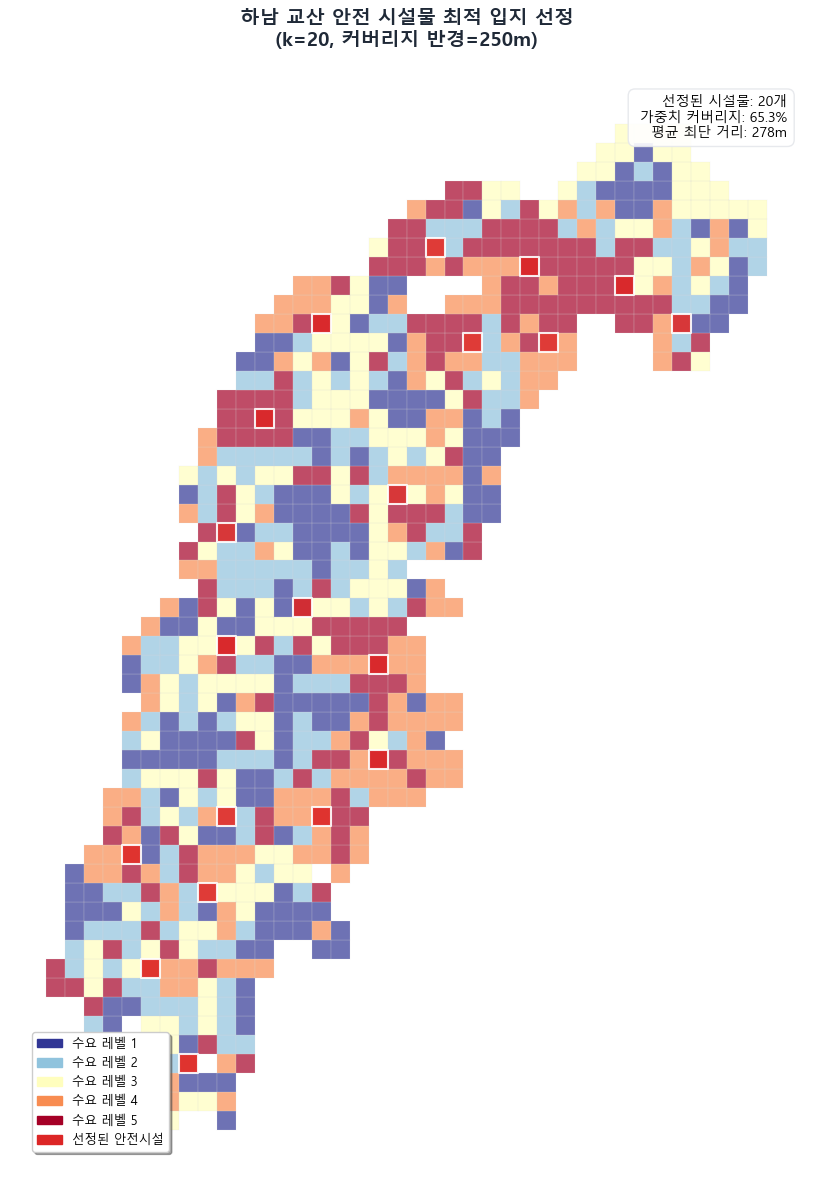

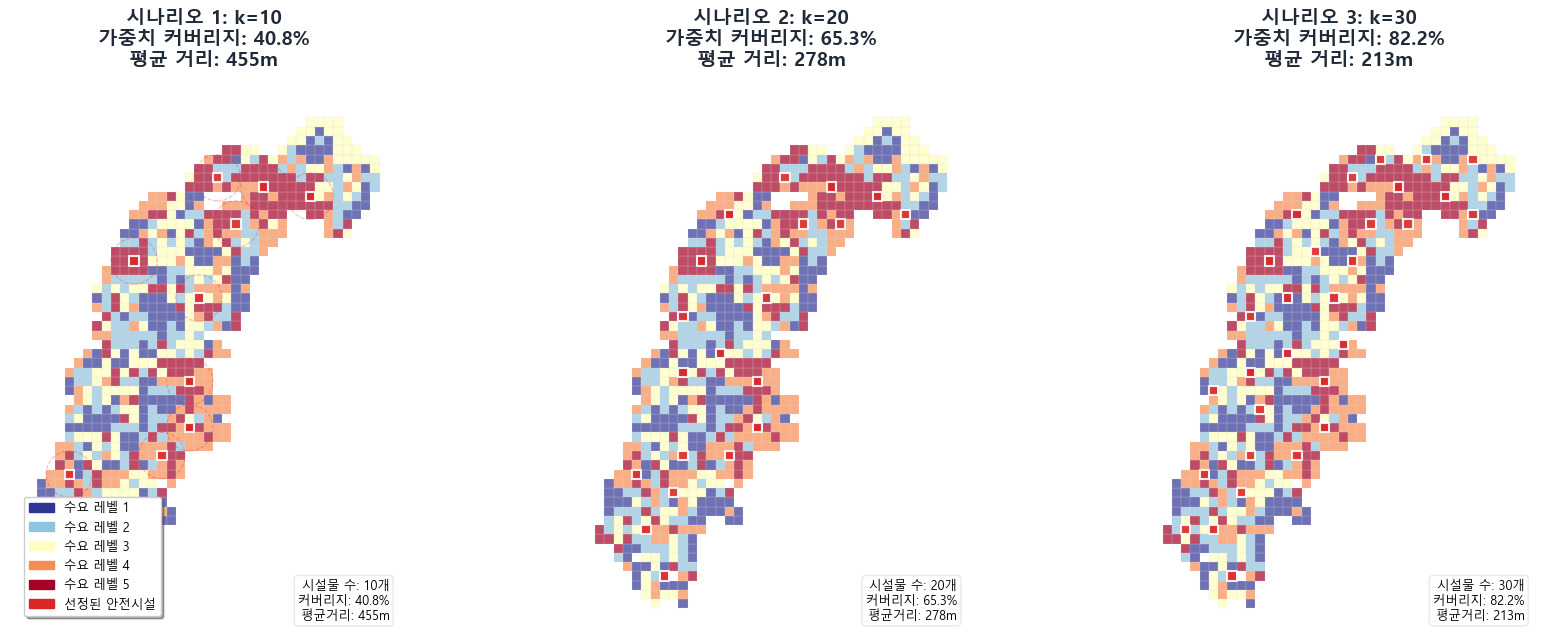


 저장된 고급화된 맵 파일:
- C:\Users\a0109\.jupyter\1최종_LH\data\통합_데이터\hanam_gyosan_selected_sites_k20.png
- C:\Users\a0109\.jupyter\1최종_LH\data\통합_데이터\hanam_gyosan_selected_sites_k_scenarios.png


In [14]:
# 필수 맵 시각화 출력 (필수) - 고급화된 버전
map_png_main = output_dir / 'hanam_gyosan_selected_sites_k20.png'
map_png_scenarios = output_dir / 'hanam_gyosan_selected_sites_k_scenarios.png'

plot_base = gdf_m.copy()
# 수요 가중치를 5개 구간으로 분할하여 시각화 준비
plot_base['w_q'] = pd.qcut(
    plot_base['demand_weight'].rank(method='first'),
    q=5,
    labels=False,
    duplicates='drop'
)

# 고급화된 색상 팔레트 설정
import matplotlib.colors as mcolors
from matplotlib.patches import Circle
import matplotlib.patches as mpatches

def draw_enhanced_base_map(ax, selected_gdf, title, show_legend=True):
    """고급화된 기본 맵 그리기 함수"""
    # 배경으로 수요 가중치 히트맵 표시 (개선된 색상)
    cmap = plt.cm.RdYlBu_r  # 더 전문적인 색상 맵
    norm = mcolors.BoundaryNorm(np.arange(0, 6), cmap.N)
    
    # 수요 가중치 히트맵
    plot_base.plot(
        column='w_q', 
        cmap=cmap, 
        linewidth=0.1, 
        edgecolor='#f0f0f0', 
        ax=ax, 
        alpha=0.7,
        legend=False
    )
    
    # 격자 경계선 (더 미세하게)
    gdf_m.boundary.plot(ax=ax, linewidth=0.15, color='#d0d0d0', alpha=0.4)

    # 선택된 안전 시설물 위치 표시 (고급화된 스타일)
    if selected_gdf is not None and len(selected_gdf) > 0:
        # 시설물 위치를 더 눈에 잘 띄게
        selected_gdf.plot(
            ax=ax,
            color='#dc2626',  # 더 선명한 빨간색
            markersize=35,
            marker='*',
            edgecolor='white',
            linewidth=1.5,
            alpha=0.9,
            zorder=10
        )
        
        # 시설물 주변에 커버리지 반경 표시 (선택적으로)
        if len(selected_gdf) <= 10:  # 너무 많으면 복잡해져서 제한
            for _, row in selected_gdf.iterrows():
                circle = Circle(
                    (row.geometry.centroid.x, row.geometry.centroid.y),
                    radius_m,
                    fill=False,
                    edgecolor='#dc2626',
                    linewidth=0.8,
                    alpha=0.3,
                    linestyle='--',
                    zorder=5
                )
                ax.add_patch(circle)

    # 제목 스타일 개선
    ax.set_title(
        title, 
        fontsize=14, 
        fontweight='bold', 
        color='#1f2937',
        pad=20
    )
    
    # 축 스타일 개선
    ax.set_axis_off()
    
    # 범례 추가 (선택적)
    if show_legend and selected_gdf is not None and len(selected_gdf) > 0:
        # 수요 가중치 범례
        legend_elements = [
            mpatches.Patch(color=cmap(i/4), label=f'수요 레벨 {i+1}') 
            for i in range(5)
        ]
        legend_elements.append(
            mpatches.Patch(color='#dc2626', label='선정된 안전시설')
        )
        
        ax.legend(
            handles=legend_elements,
            loc='lower left',
            bbox_to_anchor=(0.02, 0.02),
            frameon=True,
            fancybox=True,
            shadow=True,
            fontsize=9
        )

def create_enhanced_main_map():
    """고급화된 메인 맵 생성"""
    k_ref = 20
    sel_idx_ref = scenario_selected.get(k_ref, {}).get('sel_idx', [])
    selected = cand_df.iloc[sel_idx_ref].copy().reset_index(drop=True)
    
    # 그림 크기와 DPI 개선
    fig, ax = plt.subplots(figsize=(12, 12), dpi=100)
    fig.patch.set_facecolor('#ffffff')
    ax.set_facecolor('#fafafa')
    
    # 메인 맵 그리기
    draw_enhanced_base_map(
        ax, 
        selected, 
        f'하남 교산 안전 시설물 최적 입지 선정\n(k={k_ref}, 커버리지 반경={int(radius_m)}m)'
    )
    
    # 통계 정보 추가
    coverage_info = scenario_summary[scenario_summary['k'] == k_ref].iloc[0]
    info_text = (
        f' 선정된 시설물: {len(selected)}개\n'
        f' 가중치 커버리지: {coverage_info["weighted_coverage_ratio"]*100:.1f}%\n'
        f' 평균 최단 거리: {coverage_info["mean_nearest_distance_m"]:.0f}m'
    )
    
    ax.text(
        0.98, 0.98, info_text,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#e5e7eb'),
        zorder=15
    )
    
    plt.tight_layout()
    fig.savefig(map_png_main, dpi=300, bbox_inches='tight', facecolor='#ffffff')
    plt.show()
    return fig

def create_enhanced_scenarios_map():
    """고급화된 시나리오 비교 맵 생성"""
    n = len(scenario_ks)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 7), dpi=100, constrained_layout=True)
    fig.patch.set_facecolor('#ffffff')
    
    if n == 1:
        axes = [axes]
    
    for i, (ax, k) in enumerate(zip(axes, scenario_ks)):
        ax.set_facecolor('#fafafa')
        
        sel_idx = scenario_selected.get(k, {}).get('sel_idx', [])
        sel_k = cand_df.iloc[sel_idx].copy()

        row = scenario_summary[scenario_summary['k'] == k]
        cov_w = float(row['weighted_coverage_ratio'].iloc[0] * 100) if len(row) else np.nan
        mean_dist = float(row['mean_nearest_distance_m'].iloc[0]) if len(row) else np.nan
        
        # 시나리오 맵 그리기
        draw_enhanced_base_map(
            ax, 
            sel_k, 
            f'시나리오 {i+1}: k={k}\n가중치 커버리지: {cov_w:.1f}%\n평균 거리: {mean_dist:.0f}m',
            show_legend=(i == 0)  # 첫 번째 맵에만 범례 표시
        )
        
        # 시나리오별 통계 정보
        stats_text = (
            f'시설물 수: {len(sel_k)}개\n'
            f'커버리지: {cov_w:.1f}%\n'
            f'평균거리: {mean_dist:.0f}m'
        )
        
        ax.text(
            0.98, 0.02, stats_text,
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment='bottom',
            horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='#e5e7eb'),
            zorder=15
        )
    
    plt.tight_layout()
    fig.savefig(map_png_scenarios, dpi=300, bbox_inches='tight', facecolor='#ffffff')
    plt.show()
    return fig

# 고급화된 맵 생성
print(" 고급화된 지도 시각화를 생성합니다...")
fig_main = create_enhanced_main_map()
fig_scenarios = create_enhanced_scenarios_map()

print('\n 저장된 고급화된 맵 파일:')
print('-', map_png_main)
print('-', map_png_scenarios)

In [15]:
save_outputs = True

scenario_csv = output_dir / 'hanam_gyosan_safety_site_scenario_summary.csv'
selected_csv = output_dir / 'hanam_gyosan_safety_site_selected_k20.csv'
selected_geojson = output_dir / 'hanam_gyosan_safety_site_selected_k20.geojson'

if save_outputs:
    scenario_summary.to_csv(scenario_csv, index=False, encoding='utf-8-sig')
    pd.DataFrame(selected.drop(columns='geometry')).to_csv(selected_csv, index=False, encoding='utf-8-sig')
    selected.to_file(selected_geojson, driver='GeoJSON')

print('saved files:')
print('-', scenario_csv)
print('-', selected_csv)
print('-', selected_geojson)

# Map outputs are mandatory for this notebook
map_png_main = output_dir / 'hanam_gyosan_selected_sites_k20.png'
map_png_scenarios = output_dir / 'hanam_gyosan_selected_sites_k_scenarios.png'

print('- map_main     :', map_png_main, '| exists =', map_png_main.exists())
print('- map_scenarios:', map_png_scenarios, '| exists =', map_png_scenarios.exists())
if not (map_png_main.exists() and map_png_scenarios.exists()):
    print('WARNING: Run the map visualization cell first to generate required map outputs.')


saved files:
- C:\Users\a0109\.jupyter\1최종_LH\data\통합_데이터\hanam_gyosan_safety_site_scenario_summary.csv
- C:\Users\a0109\.jupyter\1최종_LH\data\통합_데이터\hanam_gyosan_safety_site_selected_k20.csv
- C:\Users\a0109\.jupyter\1최종_LH\data\통합_데이터\hanam_gyosan_safety_site_selected_k20.geojson
- map_main     : C:\Users\a0109\.jupyter\1최종_LH\data\통합_데이터\hanam_gyosan_selected_sites_k20.png | exists = True
- map_scenarios: C:\Users\a0109\.jupyter\1최종_LH\data\통합_데이터\hanam_gyosan_selected_sites_k_scenarios.png | exists = True


## 고급 분석 추가 기능

이 섹션에서는 요청된 모든 고급 분석 기능을 추가합니다:
1. 민감도 분석 (반경/가중치/안정성)
2. 최소 간격 제약 조건
3. 기존 시설물 반영 (사전 커버리지 + 후보지 제외)
4. 시설물 유형 분할 최적화 (CCTV vs 비상벨)
5. 계획 구역별 공정성 제약 조건
6. 통합 최종 시나리오 및 결과 내보내기

In [16]:
# ---------- Advanced helper functions ----------

def build_cover_matrix(demand_xy, cand_xy, radius_m):
    if len(demand_xy) == 0 or len(cand_xy) == 0:
        return np.zeros((len(demand_xy), len(cand_xy)), dtype=bool)
    d2 = ((demand_xy[:, None, :] - cand_xy[None, :, :]) ** 2).sum(axis=2)
    return d2 <= (radius_m ** 2)


def min_pair_distance(points_xy):
    if len(points_xy) < 2:
        return np.nan
    d2 = ((points_xy[:, None, :] - points_xy[None, :, :]) ** 2).sum(axis=2)
    np.fill_diagonal(d2, np.inf)
    return float(np.sqrt(d2.min()))


def calc_metrics(covered_mask, weights, demand_xy, selected_xy):
    coverage_ratio = float(covered_mask.mean()) if len(covered_mask) else 0.0
    weighted_coverage_ratio = float(weights[covered_mask].sum() / (weights.sum() + 1e-9)) if len(weights) else 0.0

    if len(selected_xy) == 0:
        mean_nearest = np.nan
    else:
        d2 = ((demand_xy[:, None, :] - selected_xy[None, :, :]) ** 2).sum(axis=2)
        mean_nearest = float(np.sqrt(d2.min(axis=1)).mean())

    return {
        'coverage_ratio': coverage_ratio,
        'weighted_coverage_ratio': weighted_coverage_ratio,
        'mean_nearest_distance_m': mean_nearest,
        'min_pair_distance_m': min_pair_distance(selected_xy),
    }


def jaccard_similarity(set_a, set_b):
    union = set_a | set_b
    if len(union) == 0:
        return 1.0
    return len(set_a & set_b) / len(union)


def greedy_max_coverage_constrained(
    demand_xy,
    cand_xy,
    weights,
    radius_m=250.0,
    k=20,
    blocked_cand_mask=None,
    precovered_demand_mask=None,
    min_spacing_m=0.0,
    group_labels=None,
    min_per_group=None,
):
    cover = build_cover_matrix(demand_xy, cand_xy, radius_m)

    n_d, n_c = cover.shape
    available = np.ones(n_c, dtype=bool)

    if blocked_cand_mask is not None:
        available &= ~np.asarray(blocked_cand_mask, dtype=bool)

    covered = np.zeros(n_d, dtype=bool)
    if precovered_demand_mask is not None:
        covered |= np.asarray(precovered_demand_mask, dtype=bool)

    if min_spacing_m > 0 and n_c > 0:
        c_d2 = ((cand_xy[:, None, :] - cand_xy[None, :, :]) ** 2).sum(axis=2)
        too_close = c_d2 < (min_spacing_m ** 2)
    else:
        too_close = None

    selected = []
    gains = []

    if group_labels is not None:
        group_labels = np.asarray(group_labels)

    group_counts = {}

    def pick_one(extra_mask=None):
        feasible = available.copy()
        if extra_mask is not None:
            feasible &= extra_mask

        if not feasible.any():
            return None, 0.0

        gain = ((~covered)[:, None] * cover * weights[:, None]).sum(axis=0)
        gain[~feasible] = -1
        j = int(np.argmax(gain))
        best_gain = float(gain[j])
        if best_gain <= 0:
            return None, best_gain
        return j, best_gain

    def apply_select(j, g):
        selected.append(j)
        gains.append(g)

        covered[:] = covered | cover[:, j]
        available[j] = False

        if too_close is not None:
            available[:] = available & (~too_close[j])

        if group_labels is not None:
            grp = group_labels[j]
            group_counts[grp] = group_counts.get(grp, 0) + 1

    # Phase A: satisfy fairness minimums first
    unmet = {}
    if (group_labels is not None) and (min_per_group is not None):
        for grp, quota in min_per_group.items():
            group_mask = group_labels == grp
            need = int(max(0, quota))

            for _ in range(need):
                if len(selected) >= k:
                    break
                j, g = pick_one(extra_mask=group_mask)
                if j is None:
                    break
                apply_select(j, g)

            unmet[grp] = max(0, need - group_counts.get(grp, 0))

    # Phase B: fill the rest globally
    while len(selected) < k:
        j, g = pick_one(extra_mask=None)
        if j is None:
            break
        apply_select(j, g)

    meta = {
        'unmet_group_quota': unmet,
        'selected_count': len(selected),
    }
    return selected, covered.copy(), gains, meta


def detect_xy_columns(df):
    lower = {c.lower(): c for c in df.columns}

    x_cands = ['lon', 'lng', 'x', 'longitude', 'coordx', '경도']
    y_cands = ['lat', 'y', 'latitude', 'coordy', '위도']

    x_col = next((lower[c] for c in x_cands if c in lower), None)
    y_col = next((lower[c] for c in y_cands if c in lower), None)

    return x_col, y_col


def load_existing_points(data_dir, keywords, metric_crs='EPSG:5179'):
    exts = {'.geojson', '.gpkg', '.shp', '.csv'}
    kw = [k.lower() for k in keywords]

    files = [
        p for p in data_dir.rglob('*')
        if p.is_file() and p.suffix.lower() in exts and any(k in p.name.lower() for k in kw)
    ]

    if not files:
        return gpd.GeoDataFrame(geometry=[], crs=metric_crs), None

    p = sorted(files)[0]

    try:
        if p.suffix.lower() == '.csv':
            tmp = read_csv_fallback(p)
            x_col, y_col = detect_xy_columns(tmp)
            if x_col is None or y_col is None:
                return gpd.GeoDataFrame(geometry=[], crs=metric_crs), str(p)

            g = gpd.GeoDataFrame(
                tmp,
                geometry=gpd.points_from_xy(
                    pd.to_numeric(tmp[x_col], errors='coerce'),
                    pd.to_numeric(tmp[y_col], errors='coerce'),
                ),
                crs='EPSG:4326',
            ).dropna(subset=['geometry'])
        else:
            g = gpd.read_file(p)
            if g.empty:
                return gpd.GeoDataFrame(geometry=[], crs=metric_crs), str(p)
            if g.crs is None:
                g = g.set_crs('EPSG:4326', allow_override=True)
            g = g.copy()
            g['geometry'] = g.geometry.centroid

        g = g.to_crs(metric_crs)
        g = g[g.geometry.notna()].copy()
        return g[['geometry']], str(p)
    except Exception:
        return gpd.GeoDataFrame(geometry=[], crs=metric_crs), str(p)


def demand_precovered_by_existing(demand_xy, existing_gdf, radius_m):
    if existing_gdf is None or len(existing_gdf) == 0:
        return np.zeros(len(demand_xy), dtype=bool)

    ex_xy = np.column_stack([existing_gdf.geometry.x.values, existing_gdf.geometry.y.values])
    d2 = ((demand_xy[:, None, :] - ex_xy[None, :, :]) ** 2).sum(axis=2)
    return (d2 <= (radius_m ** 2)).any(axis=1)


def blocked_candidates_by_existing(cand_xy, existing_gdf, exclusion_m):
    if existing_gdf is None or len(existing_gdf) == 0:
        return np.zeros(len(cand_xy), dtype=bool)

    ex_xy = np.column_stack([existing_gdf.geometry.x.values, existing_gdf.geometry.y.values])
    d2 = ((cand_xy[:, None, :] - ex_xy[None, :, :]) ** 2).sum(axis=2)
    return (d2 <= (exclusion_m ** 2)).any(axis=1)


In [17]:
# ---------- Base arrays for advanced analyses ----------
if 'scenario_summary' in globals() and (scenario_summary is not None) and (len(scenario_summary) > 0):
    base_k = int(20 if (scenario_summary['k'] == 20).any() else scenario_summary['k'].max())
else:
    base_k = 20

base_radius = 250.0
risk_n = minmax(gdf_m[SCORE_COL]).values
flow_n = minmax(gdf_m[FLOW_COL]).values
base_weights = 0.7 * risk_n + 0.3 * flow_n

demand_xy_adv = np.column_stack([gdf_m.geometry.centroid.x.values, gdf_m.geometry.centroid.y.values])
cand_xy_adv = np.column_stack([cand_df.geometry.centroid.x.values, cand_df.geometry.centroid.y.values])

print('base_k:', base_k)
print('demand grids:', len(gdf_m), '| candidates:', len(cand_df))


base_k: 20
demand grids: 770 | candidates: 657


In [18]:
# ---------- 1) 민감도 분석: 반경/가중치/안정성 ----------
# 반경 그리드: 150m에서 300m까지 50m 간격
radius_grid = [150.0, 200.0, 250.0, 300.0]
# 가중치 그리드: 위험 점수와 미성년자 유동 추정의 다양한 조합
weight_grid = [(0.5, 0.5), (0.7, 0.3), (0.9, 0.1)]  # (위험가중치, 유동가중치)

sens_rows = []
sel_sets = {}

# 각 반경과 가중치 조합에 대해 민감도 분석 실행
for r in radius_grid:
    for wr, wf in weight_grid:
        # 새로운 가중치 조합 생성
        w = wr * risk_n + wf * flow_n

        # 제약 조건이 있는 탐욕적 최대 커버리지 알고리즘 실행
        sel_idx, covered, gains, meta = greedy_max_coverage_constrained(
            demand_xy=demand_xy_adv,
            cand_xy=cand_xy_adv,
            weights=w,
            radius_m=r,
            k=base_k,
        )

        # 선택된 격자 ID 저장
        sel_gid = cand_df.iloc[sel_idx]['gid'].tolist()
        sel_set = set(sel_gid)
        sel_sets[(r, wr, wf)] = sel_set

        # 성능 지표 계산
        selected_xy = cand_xy_adv[sel_idx] if len(sel_idx) else np.empty((0, 2))
        m = calc_metrics(covered, w, demand_xy_adv, selected_xy)

        # 결과 저장
        sens_rows.append({
            'radius_m': r,
            'w_risk': wr,
            'w_flow': wf,
            'selected_count': len(sel_idx),
            **m,
        })

# 민감도 분석 결과 데이터프레임 생성
sensitivity_df = pd.DataFrame(sens_rows)
# 기준선 설정 (반경 250m, 위험/유동 가중치 0.7/0.3)
baseline_key = (250.0, 0.7, 0.3)
if baseline_key not in sel_sets:
    baseline_key = list(sel_sets.keys())[0]

baseline_set = sel_sets[baseline_key]
# 기준선과의 Jaccard 유사도 계산 (안정성 지표)
sensitivity_df['jaccard_vs_baseline'] = [
    jaccard_similarity(sel_sets[(r, wr, wf)], baseline_set)
    for r, wr, wf in zip(sensitivity_df['radius_m'], sensitivity_df['w_risk'], sensitivity_df['w_flow'])
]

sensitivity_df = sensitivity_df.sort_values(['radius_m', 'w_risk']).reset_index(drop=True)
sensitivity_df

,radius_m,w_risk,w_flow,selected_count,coverage_ratio,weighted_coverage_ratio,mean_nearest_distance_m,min_pair_distance_m,jaccard_vs_baseline
0,150.0,0.5,0.5,20,0.231169,0.373179,312.105858,316.227766,0.052632
1,150.0,0.7,0.3,20,0.229870,0.369957,348.704432,282.842712,0.052632
2,150.0,0.9,0.1,20,0.231169,0.370985,343.487873,300.000000,0.025641
3,200.0,0.5,0.5,20,0.301299,0.445356,317.133731,316.227766,0.111111
4,200.0,0.7,0.3,20,0.301299,0.445502,317.133731,316.227766,0.111111
5,200.0,0.9,0.1,20,0.296104,0.448338,310.503640,282.842712,0.052632
6,250.0,0.5,0.5,20,0.512987,0.643778,272.713727,300.000000,0.481481
7,250.0,0.7,0.3,20,0.509091,0.652752,277.860552,360.555128,1.000000
8,250.0,0.9,0.1,20,0.510390,0.658554,281.823845,400.000000,0.600000
9,300.0,0.5,0.5,20,0.642857,0.749545,259.044046,412.310563,0.212121


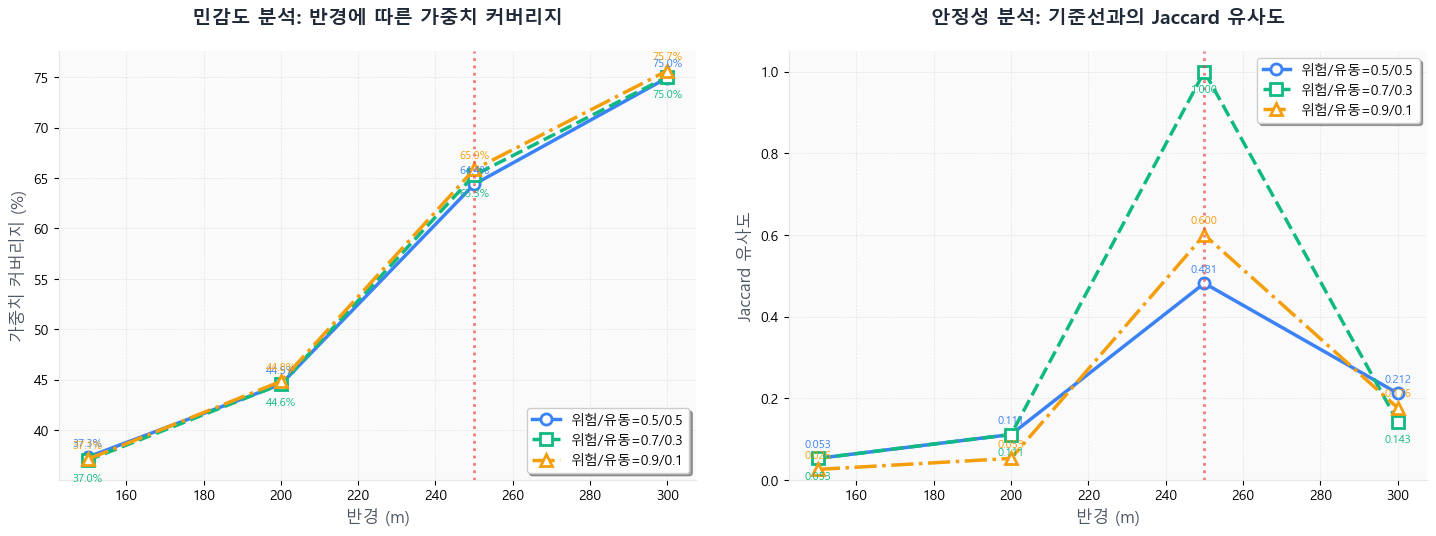

In [19]:
#  고급화된 민감도 분석 시각화: 반경 및 가중치 변화에 따른 커버리지와 안정성
fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=100)
fig.patch.set_facecolor('#ffffff')

# 고급화된 색상 팔레트
sensitivity_colors = ['#3b82f6', '#10b981', '#f59e0b']
line_styles = ['-', '--', '-.']
markers = ['o', 's', '^']

# 왼쪽: 반경에 따른 가중치 커버리지 변화 (민감도 분석)
ax1 = axes[0]
ax1.set_facecolor('#fafafa')

for i, ((wr, wf), sub) in enumerate(sensitivity_df.groupby(['w_risk', 'w_flow'])):
    ax1.plot(
        sub['radius_m'], 
        sub['weighted_coverage_ratio'] * 100, 
        marker=markers[i % len(markers)],
        color=sensitivity_colors[i % len(sensitivity_colors)],
        linestyle=line_styles[i % len(line_styles)],
        linewidth=2.5,
        markersize=8,
        markerfacecolor='white',
        markeredgewidth=2,
        label=f'위험/유동={wr:.1f}/{wf:.1f}'
    )
    
    # 데이터 포인트에 값 표시
    for _, row in sub.iterrows():
        ax1.annotate(
            f'{row["weighted_coverage_ratio"]*100:.1f}%',
            (row['radius_m'], row['weighted_coverage_ratio']*100),
            textcoords="offset points",
            xytext=(0,8) if i == 0 else (0,-15) if i == 1 else (0,8),
            ha='center',
            fontsize=8,
            color=sensitivity_colors[i % len(sensitivity_colors)]
        )

ax1.set_title(
    '민감도 분석: 반경에 따른 가중치 커버리지', 
    fontsize=14, 
    fontweight='bold', 
    color='#1f2937',
    pad=20
)
ax1.set_xlabel('반경 (m)', fontsize=12, color='#4b5563')
ax1.set_ylabel('가중치 커버리지 (%)', fontsize=12, color='#4b5563')
ax1.grid(alpha=0.3, linestyle='--', linewidth=0.5)
ax1.legend(
    loc='lower right',
    frameon=True,
    fancybox=True,
    shadow=True,
    fontsize=10
)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#e5e7eb')
ax1.spines['bottom'].set_color('#e5e7eb')

# 오른쪽: 기준선과의 Jaccard 유사도 (안정성 분석)
ax2 = axes[1]
ax2.set_facecolor('#fafafa')

for i, ((wr, wf), sub) in enumerate(sensitivity_df.groupby(['w_risk', 'w_flow'])):
    ax2.plot(
        sub['radius_m'], 
        sub['jaccard_vs_baseline'], 
        marker=markers[i % len(markers)],
        color=sensitivity_colors[i % len(sensitivity_colors)],
        linestyle=line_styles[i % len(line_styles)],
        linewidth=2.5,
        markersize=8,
        markerfacecolor='white',
        markeredgewidth=2,
        label=f'위험/유동={wr:.1f}/{wf:.1f}'
    )
    
    # 데이터 포인트에 값 표시
    for _, row in sub.iterrows():
        ax2.annotate(
            f'{row["jaccard_vs_baseline"]:.3f}',
            (row['radius_m'], row['jaccard_vs_baseline']),
            textcoords="offset points",
            xytext=(0,8) if i == 0 else (0,-15) if i == 1 else (0,8),
            ha='center',
            fontsize=8,
            color=sensitivity_colors[i % len(sensitivity_colors)]
        )

ax2.set_title(
    '안정성 분석: 기준선과의 Jaccard 유사도', 
    fontsize=14, 
    fontweight='bold', 
    color='#1f2937',
    pad=20
)
ax2.set_xlabel('반경 (m)', fontsize=12, color='#4b5563')
ax2.set_ylabel('Jaccard 유사도', fontsize=12, color='#4b5563')
ax2.set_ylim(0, 1.05)
ax2.grid(alpha=0.3, linestyle='--', linewidth=0.5)
ax2.legend(
    loc='upper right',
    frameon=True,
    fancybox=True,
    shadow=True,
    fontsize=10
)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#e5e7eb')
ax2.spines['bottom'].set_color('#e5e7eb')

# 기준선 표시
baseline_radius = 250.0
ax1.axvline(x=baseline_radius, color='#ef4444', linestyle=':', alpha=0.7, linewidth=2, label='기준선')
ax2.axvline(x=baseline_radius, color='#ef4444', linestyle=':', alpha=0.7, linewidth=2, label='기준선')

# 전체 레이아웃 조정
plt.tight_layout(pad=3.0)
plt.show()

In [20]:
# ---------- 2) Spacing Sensitivity ----------
# Derive spacing options from baseline min pair distance so spacing constraints become meaningfully testable.
sel_base, covered_base, gains_base, meta_base = greedy_max_coverage_constrained(
    demand_xy=demand_xy_adv,
    cand_xy=cand_xy_adv,
    weights=base_weights,
    radius_m=base_radius,
    k=base_k,
    min_spacing_m=0.0,
)
_base_xy = cand_xy_adv[sel_base] if len(sel_base) else np.empty((0, 2))
_base_min_pair = min_pair_distance(_base_xy)

if np.isfinite(_base_min_pair):
    spacing_options = sorted({
        0.0,
        float(max(80, round(_base_min_pair * 0.6 / 10) * 10)),
        float(max(120, round(_base_min_pair * 0.9 / 10) * 10)),
        float(max(160, round(_base_min_pair * 1.2 / 10) * 10)),
    })
else:
    spacing_options = [0.0, 200.0, 300.0, 400.0]

print('spacing_options(m):', spacing_options, '| baseline_min_pair(m):', _base_min_pair)

spacing_rows = []
spacing_sel = {}

for spacing_m in spacing_options:
    sel_idx, covered, gains, meta = greedy_max_coverage_constrained(
        demand_xy=demand_xy_adv,
        cand_xy=cand_xy_adv,
        weights=base_weights,
        radius_m=base_radius,
        k=base_k,
        min_spacing_m=spacing_m,
    )

    selected_xy = cand_xy_adv[sel_idx] if len(sel_idx) else np.empty((0, 2))
    m = calc_metrics(covered, base_weights, demand_xy_adv, selected_xy)

    spacing_rows.append({
        'min_spacing_m': spacing_m,
        'selected_count': len(sel_idx),
        **m,
    })
    spacing_sel[spacing_m] = set(cand_df.iloc[sel_idx]['gid'].tolist())

spacing_df = pd.DataFrame(spacing_rows).sort_values('min_spacing_m').reset_index(drop=True)
spacing_df['jaccard_vs_no_spacing'] = spacing_df['min_spacing_m'].map(
    lambda s: jaccard_similarity(spacing_sel[s], spacing_sel[min(spacing_options)])
)
spacing_df

spacing_options(m): [0.0, 220.0, 320.0, 430.0] | baseline_min_pair(m): 360.5551275464958


,min_spacing_m,selected_count,coverage_ratio,weighted_coverage_ratio,mean_nearest_distance_m,min_pair_distance_m,jaccard_vs_no_spacing
0,0.0,20,0.509091,0.652752,277.860552,360.555128,1.000000
1,220.0,20,0.509091,0.652752,277.860552,360.555128,1.000000
2,320.0,20,0.509091,0.652752,277.860552,360.555128,1.000000
3,430.0,20,0.515584,0.649414,276.164792,447.213595,0.666667


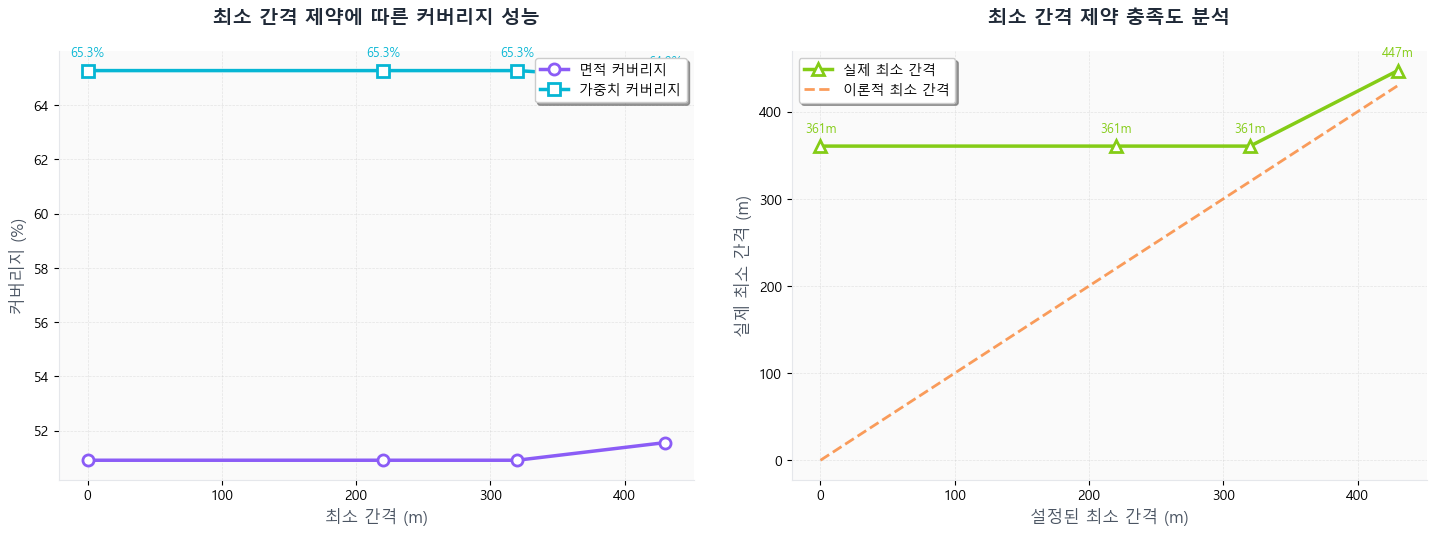

In [21]:
#  고급화된 최소 간격 제약 조건 분석 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=100)
fig.patch.set_facecolor('#ffffff')

# 색상 팔레트
constraint_colors = ['#8b5cf6', '#06b6d4', '#84cc16', '#f97316']

# 왼쪽: 최소 간격에 따른 성능 지표 변화
ax1 = axes[0]
ax1.set_facecolor('#fafafa')

# 커버리지 비율
ax1.plot(
    spacing_df['min_spacing_m'], 
    spacing_df['coverage_ratio'] * 100, 
    marker='o', 
    color=constraint_colors[0],
    linewidth=2.5,
    markersize=8,
    markerfacecolor='white',
    markeredgewidth=2,
    label='면적 커버리지'
)

# 가중치 커버리지
ax1.plot(
    spacing_df['min_spacing_m'], 
    spacing_df['weighted_coverage_ratio'] * 100, 
    marker='s', 
    color=constraint_colors[1],
    linewidth=2.5,
    markersize=8,
    markerfacecolor='white',
    markeredgewidth=2,
    label='가중치 커버리지'
)

# 데이터 포인트에 값 표시
for i, (_, row) in enumerate(spacing_df.iterrows()):
    ax1.annotate(
        f'{row["weighted_coverage_ratio"]*100:.1f}%',
        (row['min_spacing_m'], row['weighted_coverage_ratio']*100),
        textcoords="offset points",
        xytext=(0,10),
        ha='center',
        fontsize=9,
        color=constraint_colors[1]
    )

ax1.set_title(
    '최소 간격 제약에 따른 커버리지 성능', 
    fontsize=14, 
    fontweight='bold', 
    color='#1f2937',
    pad=20
)
ax1.set_xlabel('최소 간격 (m)', fontsize=12, color='#4b5563')
ax1.set_ylabel('커버리지 (%)', fontsize=12, color='#4b5563')
ax1.grid(alpha=0.3, linestyle='--', linewidth=0.5)
ax1.legend(
    loc='upper right',
    frameon=True,
    fancybox=True,
    shadow=True,
    fontsize=10
)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#e5e7eb')
ax1.spines['bottom'].set_color('#e5e7eb')

# 오른쪽: 최소 간격에 따른 최소 시설물 간 거리
ax2 = axes[1]
ax2.set_facecolor('#fafafa')

ax2.plot(
    spacing_df['min_spacing_m'], 
    spacing_df['min_pair_distance_m'], 
    marker='^', 
    color=constraint_colors[2],
    linewidth=2.5,
    markersize=8,
    markerfacecolor='white',
    markeredgewidth=2,
    label='실제 최소 간격'
)

# 기준선 (1:1 관계)
ax2.plot(
    spacing_df['min_spacing_m'], 
    spacing_df['min_spacing_m'], 
    '--', 
    color=constraint_colors[3],
    linewidth=2,
    alpha=0.7,
    label='이론적 최소 간격'
)

# 데이터 포인트에 값 표시
for i, (_, row) in enumerate(spacing_df.iterrows()):
    ax2.annotate(
        f'{row["min_pair_distance_m"]:.0f}m',
        (row['min_spacing_m'], row['min_pair_distance_m']),
        textcoords="offset points",
        xytext=(0,10),
        ha='center',
        fontsize=9,
        color=constraint_colors[2]
    )

ax2.set_title(
    '최소 간격 제약 충족도 분석', 
    fontsize=14, 
    fontweight='bold', 
    color='#1f2937',
    pad=20
)
ax2.set_xlabel('설정된 최소 간격 (m)', fontsize=12, color='#4b5563')
ax2.set_ylabel('실제 최소 간격 (m)', fontsize=12, color='#4b5563')
ax2.grid(alpha=0.3, linestyle='--', linewidth=0.5)
ax2.legend(
    loc='upper left',
    frameon=True,
    fancybox=True,
    shadow=True,
    fontsize=10
)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#e5e7eb')
ax2.spines['bottom'].set_color('#e5e7eb')

# 전체 레이아웃 조정
plt.tight_layout(pad=3.0)
plt.show()

In [22]:
# ---------- 3) Existing facility reflection ----------
# Optional auto-discovery. If no file is found, analysis still runs with empty existing sets.
existing_cctv_raw, src_cctv = load_existing_points(data_dir, ['cctv', 'camera', '\ubc29\ubc94', '\ud3d0\uc1c4\ud68c\ub85c'])
existing_bell_raw, src_bell = load_existing_points(data_dir, ['bell', 'emergency', '\ube44\uc0c1\ubca8'])

study_area = gdf_m[['geometry']].dissolve().geometry.iloc[0]

def clip_dedupe_points(points_gdf, area_geom, snap_m=5.0):
    if points_gdf is None or len(points_gdf) == 0:
        return gpd.GeoDataFrame(geometry=[], crs='EPSG:5179')

    g = points_gdf.copy()
    if g.crs is None:
        g = g.set_crs('EPSG:5179', allow_override=True)
    g = g.to_crs('EPSG:5179')

    g = g[g.geometry.notna() & g.geometry.is_valid].copy()
    g = g[g.geometry.intersects(area_geom)].copy()

    if len(g) == 0:
        return gpd.GeoDataFrame(geometry=[], crs='EPSG:5179')

    # Snap to a 5m grid and dedupe near-duplicate points.
    g['x_round'] = (g.geometry.x / snap_m).round().astype('int64')
    g['y_round'] = (g.geometry.y / snap_m).round().astype('int64')
    g = g.drop_duplicates(subset=['x_round', 'y_round']).copy()

    return g[['geometry']].reset_index(drop=True)

existing_cctv = clip_dedupe_points(existing_cctv_raw, study_area, snap_m=5.0)
existing_bell = clip_dedupe_points(existing_bell_raw, study_area, snap_m=5.0)

existing_all = pd.concat([
    existing_cctv[['geometry']] if len(existing_cctv) else gpd.GeoDataFrame(geometry=[], crs='EPSG:5179'),
    existing_bell[['geometry']] if len(existing_bell) else gpd.GeoDataFrame(geometry=[], crs='EPSG:5179')
], ignore_index=True)
existing_all = gpd.GeoDataFrame(existing_all, geometry='geometry', crs='EPSG:5179')

print('existing CCTV source :', src_cctv)
print('  - raw count      :', len(existing_cctv_raw))
print('  - clipped+dedupe :', len(existing_cctv))
print('existing Bell source :', src_bell)
print('  - raw count      :', len(existing_bell_raw))
print('  - clipped+dedupe :', len(existing_bell))
print('existing total points (study area):', len(existing_all))

precovered_existing = demand_precovered_by_existing(demand_xy_adv, existing_all, radius_m=base_radius)
blocked_existing = blocked_candidates_by_existing(cand_xy_adv, existing_all, exclusion_m=80.0)

sel_idx_ex, covered_ex, gains_ex, meta_ex = greedy_max_coverage_constrained(
    demand_xy=demand_xy_adv,
    cand_xy=cand_xy_adv,
    weights=base_weights,
    radius_m=base_radius,
    k=base_k,
    blocked_cand_mask=blocked_existing,
    precovered_demand_mask=precovered_existing,
)

selected_xy_ex = cand_xy_adv[sel_idx_ex] if len(sel_idx_ex) else np.empty((0, 2))
metrics_ex = calc_metrics(covered_ex, base_weights, demand_xy_adv, selected_xy_ex)

sel_idx_noex, covered_noex, gains_noex, meta_noex = greedy_max_coverage_constrained(
    demand_xy=demand_xy_adv,
    cand_xy=cand_xy_adv,
    weights=base_weights,
    radius_m=base_radius,
    k=base_k,
)
selected_xy_noex = cand_xy_adv[sel_idx_noex] if len(sel_idx_noex) else np.empty((0, 2))
metrics_noex = calc_metrics(covered_noex, base_weights, demand_xy_adv, selected_xy_noex)

existing_effect_df = pd.DataFrame([
    {
        'scenario': 'without_existing',
        'precovered_by_existing_ratio': 0.0,
        'blocked_candidate_ratio': 0.0,
        'selected_count': len(sel_idx_noex),
        **metrics_noex,
    },
    {
        'scenario': 'with_existing_reflection',
        'precovered_by_existing_ratio': float(precovered_existing.mean()),
        'blocked_candidate_ratio': float(blocked_existing.mean()),
        'selected_count': len(sel_idx_ex),
        **metrics_ex,
    },
])

existing_effect_df

existing CCTV source : C:\Users\a0109\.jupyter\1최종_LH\data\교통_데이터\20._CCTV_현황.csv
  - raw count      : 28347
  - clipped+dedupe : 102
existing Bell source : None
  - raw count      : 0
  - clipped+dedupe : 0
existing total points (study area): 102


,scenario,precovered_by_existing_ratio,blocked_candidate_ratio,selected_count,coverage_ratio,weighted_coverage_ratio,mean_nearest_distance_m,min_pair_distance_m
0,without_existing,0.000000,0.000000,20,0.509091,0.652752,277.860552,360.555128
1,with_existing_reflection,0.733766,0.205479,20,0.968831,0.982091,338.246922,200.000000


In [23]:
# ---------- Visualization variable preparation (run-all safe) ----------
# 1) Existing/spacing summaries
if 'existing_effect_df' in locals() and isinstance(existing_effect_df, pd.DataFrame) and len(existing_effect_df):
    _tmp = existing_effect_df[existing_effect_df['scenario'] == 'with_existing_reflection']
    if len(_tmp) == 0:
        _tmp = existing_effect_df.iloc[[-1]]
    existing_summary = _tmp.iloc[0]
else:
    existing_summary = pd.Series({'weighted_coverage_ratio': 0.0, 'mean_nearest_distance_m': np.nan})

if 'spacing_df' in locals() and isinstance(spacing_df, pd.DataFrame) and len(spacing_df):
    _idx = spacing_df['min_spacing_m'].idxmax()
    spacing_summary = spacing_df.loc[_idx]
else:
    spacing_summary = pd.Series({'weighted_coverage_ratio': 0.0, 'mean_nearest_distance_m': np.nan, 'min_spacing_m': np.nan})

# 2) Facility config and split results
if 'facility_cfg' not in locals():
    _total_k = int(base_k if 'base_k' in locals() else 20)
    _k_cctv = max(1, int(round(_total_k * 0.6)))
    _k_bell = max(1, _total_k - _k_cctv)

    facility_cfg = {
        'CCTV': {
            'k': _k_cctv,
            'radius_m': 250.0,
            'min_spacing_m': 140.0,
            'existing_cover_radius_m': 250.0,
            'existing_exclusion_m': 80.0,
            'weights': (0.75, 0.25),
            'color': '#2563eb',
        },
        'EmergencyBell': {
            'k': _k_bell,
            'radius_m': 150.0,
            'min_spacing_m': 100.0,
            'existing_cover_radius_m': 150.0,
            'existing_exclusion_m': 50.0,
            'weights': (0.55, 0.45),
            'color': '#dc2626',
        },
    }

if ('facility_summary_df' not in locals()) or (not isinstance(facility_summary_df, pd.DataFrame)) or (len(facility_summary_df) == 0) or ('facility_selected_gdf' not in locals()):
    _rows = []
    _sel_list = []

    for _fac_name, _cfg in facility_cfg.items():
        # Split candidate pools by road-share heuristic (CCTV near roads, bells elsewhere).
        if _fac_name == 'CCTV':
            _fac_cand = gdf_m[gdf_m['is_candidate'] & (gdf_m[ROAD_COL] > 0)].copy()
            _existing_points = existing_cctv if 'existing_cctv' in locals() else gpd.GeoDataFrame(geometry=[], crs='EPSG:5179')
        else:
            _fac_cand = gdf_m[gdf_m['is_candidate'] & (gdf_m[ROAD_COL] <= 0)].copy()
            _existing_points = existing_bell if 'existing_bell' in locals() else gpd.GeoDataFrame(geometry=[], crs='EPSG:5179')

        if len(_fac_cand) < _cfg['k']:
            _fac_cand = gdf_m[gdf_m['is_candidate']].copy()

        if len(_fac_cand) == 0:
            _rows.append({
                'facility': _fac_name,
                'k': _cfg['k'],
                'candidate_count': 0,
                'selected_count': 0,
                'coverage_ratio': np.nan,
                'weighted_coverage_ratio': np.nan,
                'mean_nearest_distance_m': np.nan,
                'min_pair_distance_m': np.nan,
            })
            continue

        _fac_xy = np.column_stack([_fac_cand.geometry.centroid.x.values, _fac_cand.geometry.centroid.y.values])
        _wr, _wf = _cfg['weights']
        _w = _wr * risk_n + _wf * flow_n

        _pre = demand_precovered_by_existing(demand_xy_adv, _existing_points, _cfg['existing_cover_radius_m'])
        _blocked = blocked_candidates_by_existing(_fac_xy, _existing_points, _cfg['existing_exclusion_m'])

        _sel_idx, _covered, _gains, _meta = greedy_max_coverage_constrained(
            demand_xy=demand_xy_adv,
            cand_xy=_fac_xy,
            weights=_w,
            radius_m=_cfg['radius_m'],
            k=_cfg['k'],
            blocked_cand_mask=_blocked,
            precovered_demand_mask=_pre,
            min_spacing_m=_cfg['min_spacing_m'],
        )

        _sel = _fac_cand.iloc[_sel_idx].copy().reset_index(drop=True)
        _sel['facility'] = _fac_name
        _sel['selected_order'] = np.arange(1, len(_sel) + 1)
        _sel['incremental_gain'] = pd.Series(_gains)
        _sel_list.append(_sel)

        _sel_xy = _fac_xy[_sel_idx] if len(_sel_idx) else np.empty((0, 2))
        _m = calc_metrics(_covered, _w, demand_xy_adv, _sel_xy)

        _rows.append({
            'facility': _fac_name,
            'k': _cfg['k'],
            'candidate_count': len(_fac_cand),
            'selected_count': len(_sel_idx),
            **_m,
        })

    facility_summary_df = pd.DataFrame(_rows)
    facility_selected_gdf = gpd.GeoDataFrame(
        pd.concat(_sel_list, ignore_index=True) if len(_sel_list) else pd.DataFrame(columns=['facility', 'geometry']),
        geometry='geometry',
        crs=gdf_m.crs,
    )

# cell 26/28 backward compatibility
facility_summary = facility_summary_df.copy()

# 3) Fairness summary and selections (run-all safe fallback)
if ('sel_u' not in locals()) or ('sel_f' not in locals()) or ('x_med' not in locals()) or ('y_med' not in locals()):
    _cent = cand_df.geometry.centroid
    x_med = float(_cent.x.median())
    y_med = float(_cent.y.median())

    _zone = np.where(
        (_cent.x <= x_med) & (_cent.y <= y_med), 'SW',
        np.where((_cent.x > x_med) & (_cent.y <= y_med), 'SE', np.where((_cent.x <= x_med) & (_cent.y > y_med), 'NW', 'NE'))
    )

    _zone_vals = sorted(pd.Series(_zone).unique().tolist())
    # Make quota binding for base_k=20 and 4 zones (target: 5 each).
    _min_each = max(1, int(np.floor(base_k / max(1, len(_zone_vals)))))
    if _min_each * len(_zone_vals) > base_k:
        _min_each = max(1, base_k // len(_zone_vals))
    _min_per_zone = {z: _min_each for z in _zone_vals}

    sel_u, cov_u, gain_u, meta_u = greedy_max_coverage_constrained(
        demand_xy=demand_xy_adv,
        cand_xy=cand_xy_adv,
        weights=base_weights,
        radius_m=base_radius,
        k=base_k,
    )

    sel_f, cov_f, gain_f, meta_f = greedy_max_coverage_constrained(
        demand_xy=demand_xy_adv,
        cand_xy=cand_xy_adv,
        weights=base_weights,
        radius_m=base_radius,
        k=base_k,
        group_labels=_zone,
        min_per_group=_min_per_zone,
    )

    _sel_u_xy = cand_xy_adv[sel_u] if len(sel_u) else np.empty((0, 2))
    _sel_f_xy = cand_xy_adv[sel_f] if len(sel_f) else np.empty((0, 2))
    _mu = calc_metrics(cov_u, base_weights, demand_xy_adv, _sel_u_xy)
    _mf = calc_metrics(cov_f, base_weights, demand_xy_adv, _sel_f_xy)

    _dist_u = pd.Series(_zone[np.array(sel_u, dtype=int)]).value_counts().to_dict() if len(sel_u) else {}
    _dist_f = pd.Series(_zone[np.array(sel_f, dtype=int)]).value_counts().to_dict() if len(sel_f) else {}

    fairness_compare_df = pd.DataFrame([
        {'scenario': 'unconstrained', **_mu, 'zone_distribution': str(_dist_u), 'quota': str({})},
        {'scenario': 'fairness_constrained', **_mf, 'zone_distribution': str(_dist_f), 'quota': str(_min_per_zone)},
    ])

if 'fairness_summary' not in locals():
    if 'fairness_compare_df' in locals() and isinstance(fairness_compare_df, pd.DataFrame) and len(fairness_compare_df):
        _fr = fairness_compare_df[fairness_compare_df['scenario'] == 'fairness_constrained']
        if len(_fr) == 0:
            _fr = fairness_compare_df.iloc[[-1]]
        fairness_summary = _fr.iloc[0]
    else:
        fairness_summary = pd.Series({'weighted_coverage_ratio': 0.0, 'mean_nearest_distance_m': np.nan})

# 4) Combined placeholders for export/map cells
if 'combined_selected_gdf' not in locals():
    combined_selected_gdf = facility_selected_gdf.copy()

if 'combined_summary_df' not in locals():
    combined_summary_df = facility_summary_df.copy()


# 5) Harmonized scenario comparison metrics (same basis)
def _xy_from_gdf(_gdf):
    if _gdf is None or len(_gdf) == 0:
        return np.empty((0, 2))
    _geom = _gdf.geometry
    _geom = _geom[_geom.notna() & _geom.is_valid]
    if len(_geom) == 0:
        return np.empty((0, 2))
    _c = _geom.centroid
    return np.column_stack([_c.x.values, _c.y.values])


def _cover_mask_single_radius(_demand_xy, _points_xy, _radius_m):
    if len(_points_xy) == 0:
        return np.zeros(len(_demand_xy), dtype=bool)
    _d2 = ((_demand_xy[:, None, :] - _points_xy[None, :, :]) ** 2).sum(axis=2)
    return (_d2 <= (_radius_m ** 2)).any(axis=1)


def _mean_nearest_distance(_demand_xy, _points_xy):
    if len(_points_xy) == 0:
        return np.nan
    _d2 = ((_demand_xy[:, None, :] - _points_xy[None, :, :]) ** 2).sum(axis=2)
    return float(np.sqrt(_d2.min(axis=1)).mean())


def _weighted_ratio(_mask, _weights):
    if len(_weights) == 0:
        return 0.0
    return float(_weights[_mask].sum() / (_weights.sum() + 1e-9))


def _scenario_row(_key, _label, _basis, _new_xy, _service_xy, _mask_total, _mask_incr, _existing_count=0, _note=''):
    return {
        'scenario_key': _key,
        'scenario_label': _label,
        'basis': _basis,
        'selected_count': int(len(_new_xy)),
        'existing_count': int(_existing_count),
        'coverage_total_ratio': float(_mask_total.mean()),
        'weighted_total_ratio': _weighted_ratio(_mask_total, base_weights),
        'coverage_increment_ratio': float(_mask_incr.mean()),
        'weighted_increment_ratio': _weighted_ratio(_mask_incr, base_weights),
        'mean_nearest_distance_m': _mean_nearest_distance(demand_xy_adv, _service_xy),
        'min_pair_distance_m': min_pair_distance(_new_xy),
        'note': _note,
    }


_scenario_rows = []

# A) Basic scenario (new-only, radius=base_radius)
_basic_idx = None
if 'sel_idx_noex' in locals():
    _basic_idx = np.array(sel_idx_noex, dtype=int)
elif 'scenario_selected' in locals() and isinstance(scenario_selected, dict) and (base_k in scenario_selected):
    _basic_idx = np.array(scenario_selected[base_k].get('sel_idx', []), dtype=int)
else:
    _basic_idx = np.array([], dtype=int)

_basic_xy = cand_xy_adv[_basic_idx] if len(_basic_idx) else np.empty((0, 2))
_basic_mask = _cover_mask_single_radius(demand_xy_adv, _basic_xy, base_radius)
_scenario_rows.append(
    _scenario_row(
        'basic_new',
        'Basic (New)',
        'new_only',
        _basic_xy,
        _basic_xy,
        _basic_mask,
        _basic_mask,
        _existing_count=0,
        _note=f'base radius={base_radius:.0f}m',
    )
)

# B) Existing-reflection scenario (total and incremental split)
_existing_xy = _xy_from_gdf(existing_all if 'existing_all' in locals() else gpd.GeoDataFrame(geometry=[], crs=gdf_m.crs))
_existing_mask = _cover_mask_single_radius(demand_xy_adv, _existing_xy, base_radius)

_ex_idx = np.array(sel_idx_ex, dtype=int) if 'sel_idx_ex' in locals() else np.array([], dtype=int)
_ex_new_xy = cand_xy_adv[_ex_idx] if len(_ex_idx) else np.empty((0, 2))
_ex_new_mask = _cover_mask_single_radius(demand_xy_adv, _ex_new_xy, base_radius)
_ex_total_mask = _existing_mask | _ex_new_mask
_ex_incr_mask = _ex_total_mask & (~_existing_mask)

if len(_existing_xy) and len(_ex_new_xy):
    _ex_service_xy = np.vstack([_existing_xy, _ex_new_xy])
elif len(_existing_xy):
    _ex_service_xy = _existing_xy
else:
    _ex_service_xy = _ex_new_xy

_scenario_rows.append(
    _scenario_row(
        'existing_total',
        'Existing Reflected (Total)',
        'existing_plus_new',
        _ex_new_xy,
        _ex_service_xy,
        _ex_total_mask,
        _ex_incr_mask,
        _existing_count=len(_existing_xy),
        _note='total=existing union new, increment=new-only gain over existing',
    )
)

# C) Spacing-constrained scenario (use strongest spacing constraint)
if 'spacing_df' in locals() and isinstance(spacing_df, pd.DataFrame) and len(spacing_df):
    _spacing_target = float(spacing_df['min_spacing_m'].max())
else:
    _spacing_target = 0.0

_spacing_idx = np.array([], dtype=int)
if 'spacing_sel' in locals() and isinstance(spacing_sel, dict) and (_spacing_target in spacing_sel):
    _gid_set = set(spacing_sel[_spacing_target])
    _cand_gid = cand_df['gid'].reset_index(drop=True)
    _spacing_idx = np.where(_cand_gid.isin(_gid_set).values)[0]
else:
    _spacing_idx, _, _, _ = greedy_max_coverage_constrained(
        demand_xy=demand_xy_adv,
        cand_xy=cand_xy_adv,
        weights=base_weights,
        radius_m=base_radius,
        k=base_k,
        min_spacing_m=_spacing_target,
    )
    _spacing_idx = np.array(_spacing_idx, dtype=int)

_spacing_xy = cand_xy_adv[_spacing_idx] if len(_spacing_idx) else np.empty((0, 2))
_spacing_mask = _cover_mask_single_radius(demand_xy_adv, _spacing_xy, base_radius)
_scenario_rows.append(
    _scenario_row(
        'spacing_new',
        'Existing Reflected (Total)',
        'new_only',
        _spacing_xy,
        _spacing_xy,
        _spacing_mask,
        _spacing_mask,
        _existing_count=0,
        _note=f'min_spacing={_spacing_target:.0f}m',
    )
)

# D) Facility-split scenario (new-only union across facility-specific radii)
_fac_union_mask = np.zeros(len(demand_xy_adv), dtype=bool)
_fac_new_xy = _xy_from_gdf(facility_selected_gdf if 'facility_selected_gdf' in locals() else gpd.GeoDataFrame(geometry=[], crs=gdf_m.crs))

if 'facility_selected_gdf' in locals() and len(facility_selected_gdf) and 'facility_cfg' in locals():
    for _fac_name, _cfg in facility_cfg.items():
        _sub = facility_selected_gdf[facility_selected_gdf['facility'] == _fac_name]
        _sub_xy = _xy_from_gdf(_sub)
        _fac_union_mask |= _cover_mask_single_radius(demand_xy_adv, _sub_xy, float(_cfg.get('radius_m', base_radius)))

_scenario_rows.append(
    _scenario_row(
        'split_union_new',
        'Type-Split (New Union)',
        'new_only',
        _fac_new_xy,
        _fac_new_xy,
        _fac_union_mask,
        _fac_union_mask,
        _existing_count=0,
        _note='CCTV and EmergencyBell union coverage with type-specific radii',
    )
)

# E) Fairness-constrained scenario (new-only)
_fair_idx = np.array(sel_f, dtype=int) if 'sel_f' in locals() else np.array([], dtype=int)
_fair_xy = cand_xy_adv[_fair_idx] if len(_fair_idx) else np.empty((0, 2))
_fair_mask = _cover_mask_single_radius(demand_xy_adv, _fair_xy, base_radius)
_scenario_rows.append(
    _scenario_row(
        'fairness_new',
        'Fairness (New)',
        'new_only',
        _fair_xy,
        _fair_xy,
        _fair_mask,
        _fair_mask,
        _existing_count=0,
        _note='quadrant quota constrained selection',
    )
)

scenario_compare_df = pd.DataFrame(_scenario_rows)
_order = ['basic_new', 'existing_total', 'spacing_new', 'split_union_new', 'fairness_new']
scenario_compare_df = scenario_compare_df.set_index('scenario_key').loc[_order].reset_index()
_label_map = {
    'basic_new': '\uae30\ubcf8(\uc2e0\uaddc)',
    'existing_total': '\uae30\uc874\ubc18\uc601(\ucd1d\ud569)',
    'spacing_new': '\uac04\uaca9\uc81c\uc57d(\uc2e0\uaddc)',
    'split_union_new': '\uc720\ud615\ubd84\ud560(\uc2e0\uaddc \ud1b5\ud569)',
    'fairness_new': '\uacf5\uc815\uc131(\uc2e0\uaddc)',
}
scenario_compare_df['scenario_label'] = scenario_compare_df['scenario_key'].map(_label_map).fillna(scenario_compare_df['scenario_label'])
scenario_compare_df['weighted_total_pct'] = scenario_compare_df['weighted_total_ratio'] * 100.0
scenario_compare_df['weighted_increment_pct'] = scenario_compare_df['weighted_increment_ratio'] * 100.0
scenario_compare_df['coverage_total_pct'] = scenario_compare_df['coverage_total_ratio'] * 100.0
scenario_compare_df['coverage_increment_pct'] = scenario_compare_df['coverage_increment_ratio'] * 100.0


print('prep done:',
      'facility_rows=', len(facility_summary_df),
      '| facility_selected=', len(facility_selected_gdf),
      '| fairness_rows=', len(fairness_compare_df) if 'fairness_compare_df' in locals() else 0,
      '| combined_selected=', len(combined_selected_gdf))

prep done: facility_rows= 2 | facility_selected= 20 | fairness_rows= 2 | combined_selected= 20


,scenario_label,basis,selected_count,existing_count,weighted_total_pct,weighted_increment_pct,mean_nearest_distance_m,min_pair_distance_m
0,기본(신규),new_only,20,0,65.275,65.275,277.861,360.555
1,기존반영(총합),existing_plus_new,20,102,98.209,24.455,132.663,200.000
2,간격제약(신규),new_only,20,0,64.941,64.941,276.165,447.214
3,유형분할(신규 통합),new_only,20,0,37.143,37.143,359.500,141.421
4,공정성(신규),new_only,20,0,62.645,62.645,292.277,300.000


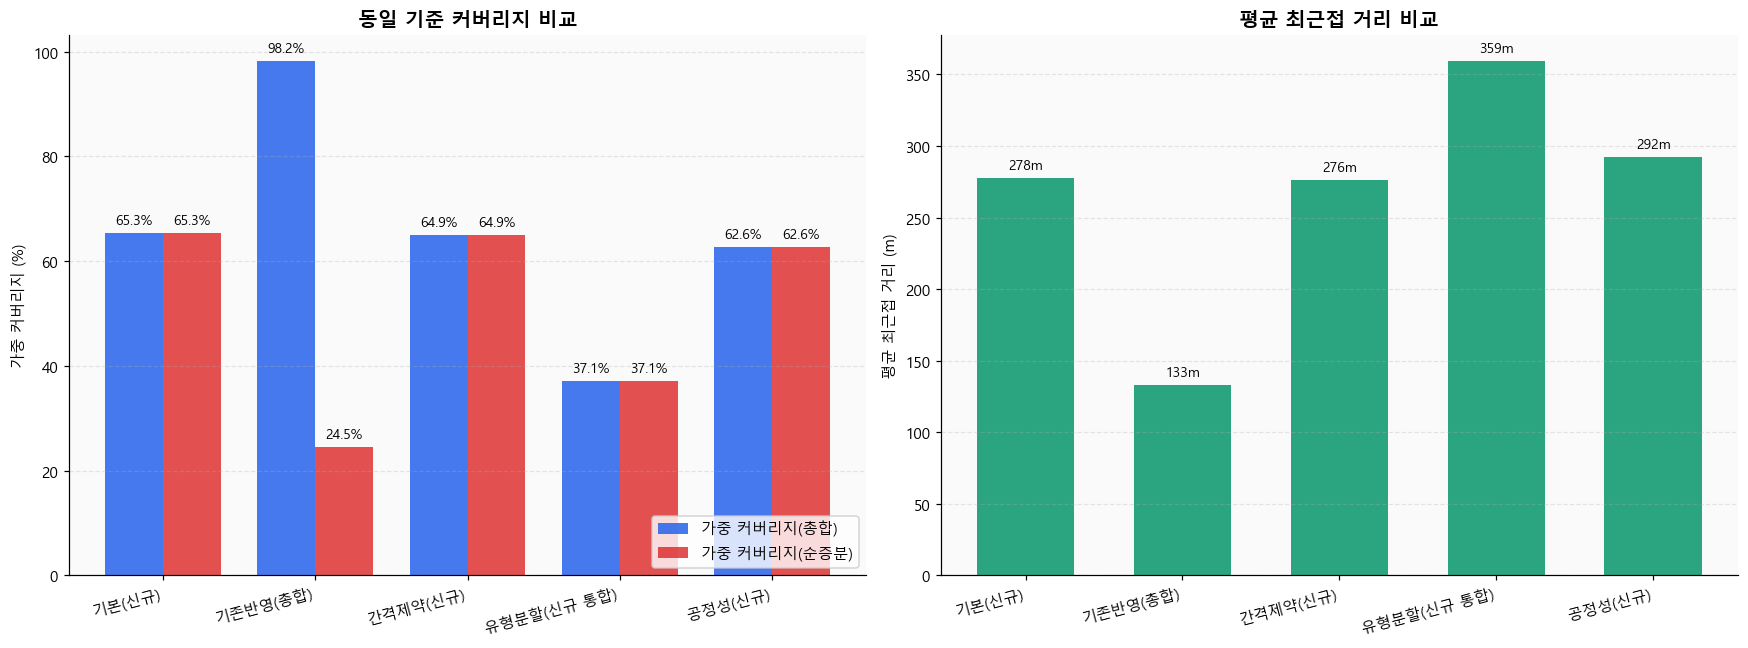

In [24]:
# 동일 기준 시나리오 비교 (총합 vs 순증분)
if 'scenario_compare_df' not in locals() or not isinstance(scenario_compare_df, pd.DataFrame) or len(scenario_compare_df) == 0:
    print('scenario_compare_df is not ready. Run previous cells first.')
else:
    display_cols = [
        'scenario_label',
        'basis',
        'selected_count',
        'existing_count',
        'weighted_total_pct',
        'weighted_increment_pct',
        'mean_nearest_distance_m',
        'min_pair_distance_m',
    ]
    _tbl = scenario_compare_df[display_cols].round(3)
    try:
        from IPython.display import display as _show
        _show(_tbl)
    except Exception:
        print(_tbl.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=110)
    fig.patch.set_facecolor('#ffffff')

    x = np.arange(len(scenario_compare_df))
    labels = scenario_compare_df['scenario_label'].tolist()
    width = 0.38

    ax1 = axes[0]
    ax1.set_facecolor('#fafafa')
    b1 = ax1.bar(x - width/2, scenario_compare_df['weighted_total_pct'], width,
                 color='#2563eb', alpha=0.85, label='\uac00\uc911 \ucee4\ubc84\ub9ac\uc9c0(\ucd1d\ud569)')
    b2 = ax1.bar(x + width/2, scenario_compare_df['weighted_increment_pct'], width,
                 color='#dc2626', alpha=0.80, label='\uac00\uc911 \ucee4\ubc84\ub9ac\uc9c0(\uc21c\uc99d\ubd84)')

    for bars in [b1, b2]:
        for bar in bars:
            h = bar.get_height()
            if np.isfinite(h):
                ax1.annotate(f'{h:.1f}%',
                             xy=(bar.get_x() + bar.get_width()/2, h),
                             xytext=(0, 4), textcoords='offset points',
                             ha='center', va='bottom', fontsize=9)

    ax1.set_title('\ub3d9\uc77c \uae30\uc900 \ucee4\ubc84\ub9ac\uc9c0 \ube44\uad50', fontsize=13, fontweight='bold')
    ax1.set_ylabel('\uac00\uc911 \ucee4\ubc84\ub9ac\uc9c0 (%)')
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels, rotation=15, ha='right')
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    ax1.legend(loc='lower right', frameon=True)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    ax2 = axes[1]
    ax2.set_facecolor('#fafafa')
    b3 = ax2.bar(x, scenario_compare_df['mean_nearest_distance_m'],
                 color='#059669', alpha=0.85, width=0.62)
    for bar in b3:
        h = bar.get_height()
        if np.isfinite(h):
            ax2.annotate(f'{h:.0f}m',
                         xy=(bar.get_x() + bar.get_width()/2, h),
                         xytext=(0, 4), textcoords='offset points',
                         ha='center', va='bottom', fontsize=9)

    ax2.set_title('\ud3c9\uade0 \ucd5c\uadfc\uc811 \uac70\ub9ac \ube44\uad50', fontsize=13, fontweight='bold')
    ax2.set_ylabel('\ud3c9\uade0 \ucd5c\uadfc\uc811 \uac70\ub9ac (m)')
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels, rotation=15, ha='right')
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()


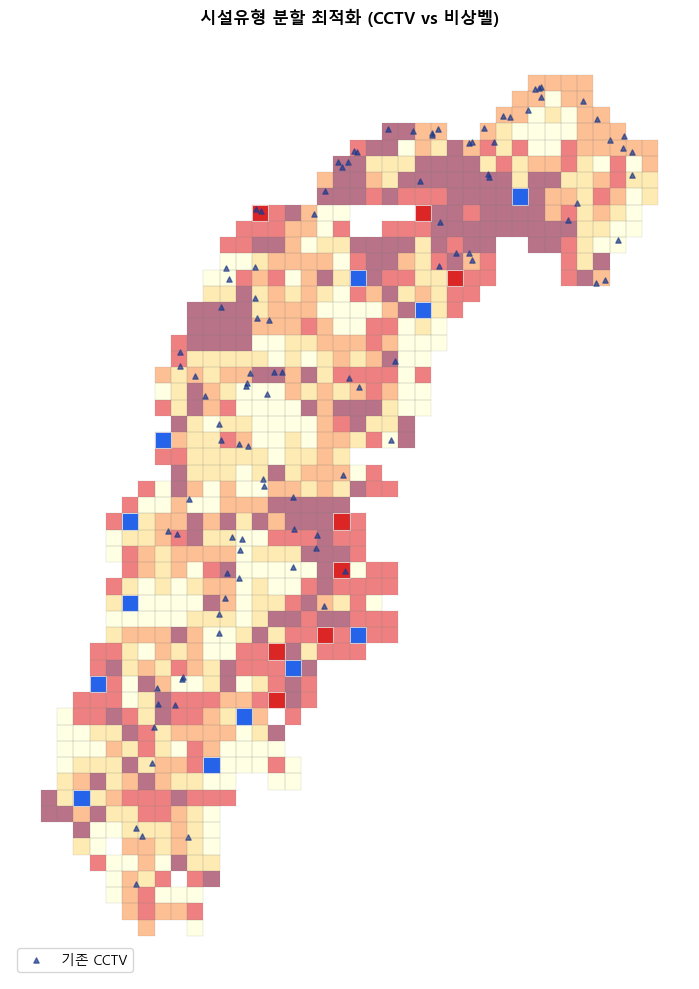

In [25]:
# Facility split map
if 'facility_cfg' not in locals():
    facility_cfg = {
        'CCTV': {'color': '#2563eb'},
        'EmergencyBell': {'color': '#dc2626'},
    }
if 'facility_selected_gdf' not in locals():
    facility_selected_gdf = gpd.GeoDataFrame(pd.DataFrame(columns=['facility']), geometry=[], crs=gdf_m.crs)

fig, ax = plt.subplots(figsize=(10, 10))

plot_base = gdf_m.copy()
plot_base['w_q'] = pd.qcut(plot_base['demand_weight'].rank(method='first'), q=5, labels=False, duplicates='drop')
plot_base.plot(column='w_q', cmap='YlOrRd', linewidth=0.05, edgecolor='none', ax=ax, alpha=0.55)
gdf_m.boundary.plot(ax=ax, linewidth=0.2, color='gray', alpha=0.5)

for fac_name, cfg in facility_cfg.items():
    if len(facility_selected_gdf):
        sub = facility_selected_gdf[facility_selected_gdf['facility'] == fac_name]
    else:
        sub = facility_selected_gdf
    if len(sub):
        sub.plot(ax=ax, color=cfg.get('color', '#2563eb'), markersize=30, marker='o', edgecolor='white', linewidth=0.5, label=fac_name)

if 'existing_cctv' in locals() and len(existing_cctv):
    existing_cctv.plot(ax=ax, color='#1e3a8a', markersize=14, marker='^', alpha=0.7, label='\uae30\uc874 CCTV')
if 'existing_bell' in locals() and len(existing_bell):
    existing_bell.plot(ax=ax, color='#7f1d1d', markersize=14, marker='^', alpha=0.7, label='\uae30\uc874 \ube44\uc0c1\ubca8')

ax.set_title('\uc2dc\uc124\uc720\ud615 \ubd84\ud560 \ucd5c\uc801\ud654 (CCTV vs \ube44\uc0c1\ubca8)', fontsize=12, fontweight='bold')
ax.set_axis_off()
handles, labels = ax.get_legend_handles_labels()
if len(handles):
    ax.legend(loc='lower left', frameon=True)
plt.tight_layout()
plt.show()


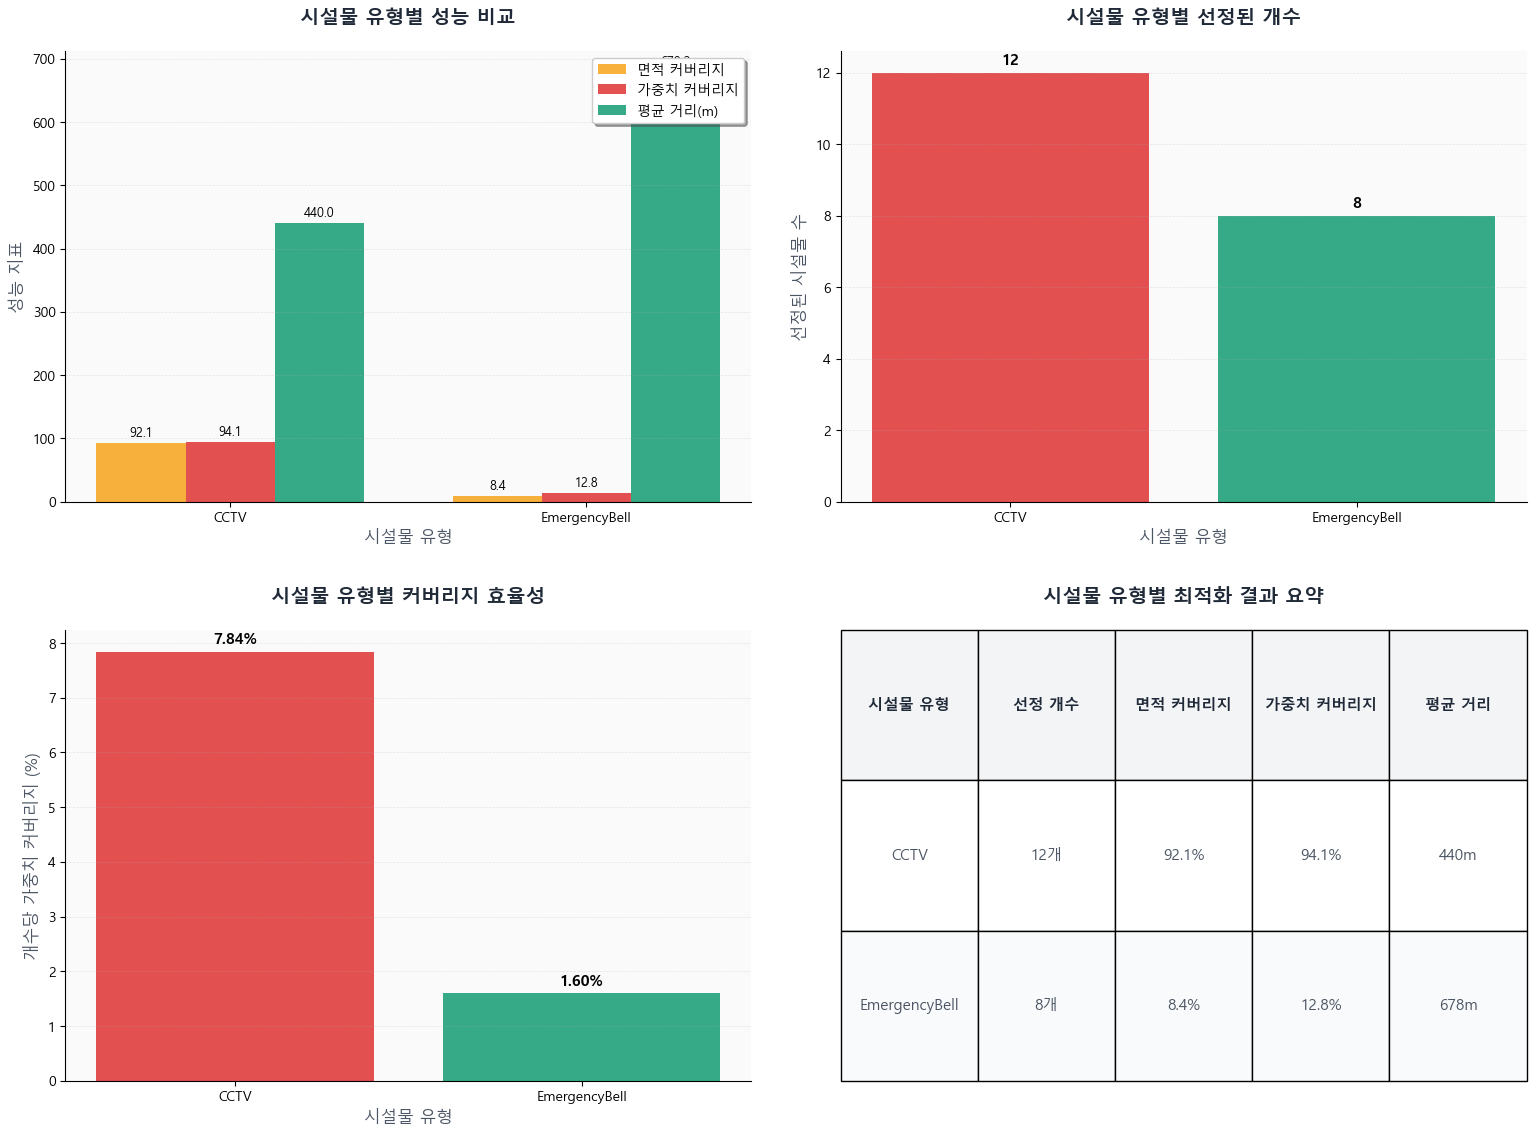

In [26]:
#  고급화된 시설물 유형 분할 최적화 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=100)
fig.patch.set_facecolor('#ffffff')

# 색상 팔레트
facility_colors = {
    'CCTV': '#dc2626',
    'EmergencyBell': '#059669',
    'Lighting': '#7c3aed',
    'total': '#f59e0b'
}

# (1) 커버리지 비교 막대 그래프
ax1 = axes[0, 0]
ax1.set_facecolor('#fafafa')

x = np.arange(len(facility_summary))
width = 0.25

bars1 = ax1.bar(x - width, facility_summary['coverage_ratio'] * 100, width, 
                label='면적 커버리지', color=facility_colors['total'], alpha=0.8)
bars2 = ax1.bar(x, facility_summary['weighted_coverage_ratio'] * 100, width,
                label='가중치 커버리지', color=facility_colors['CCTV'], alpha=0.8)
bars3 = ax1.bar(x + width, facility_summary['mean_nearest_distance_m'], width,
                label='평균 거리(m)', color=facility_colors['EmergencyBell'], alpha=0.8)

# 값 표시
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(f'{height:.1f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

ax1.set_title('시설물 유형별 성능 비교', fontsize=14, fontweight='bold', color='#1f2937', pad=20)
ax1.set_xlabel('시설물 유형', fontsize=12, color='#4b5563')
ax1.set_ylabel('성능 지표', fontsize=12, color='#4b5563')
ax1.set_xticks(x)
ax1.set_xticklabels(facility_summary['facility'])
ax1.legend(loc='upper right', frameon=True, fancybox=True, shadow=True, fontsize=10)
ax1.grid(alpha=0.3, linestyle='--', linewidth=0.5, axis='y')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# (2) 선택된 시설물 수 비교
ax2 = axes[0, 1]
ax2.set_facecolor('#fafafa')

bars = ax2.bar(facility_summary['facility'], facility_summary['selected_count'],
                color=[facility_colors['CCTV'], facility_colors['EmergencyBell']], alpha=0.8)

for bar in bars:
    height = bar.get_height()
    ax2.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_title('시설물 유형별 선정된 개수', fontsize=14, fontweight='bold', color='#1f2937', pad=20)
ax2.set_xlabel('시설물 유형', fontsize=12, color='#4b5563')
ax2.set_ylabel('선정된 시설물 수', fontsize=12, color='#4b5563')
ax2.grid(alpha=0.3, linestyle='--', linewidth=0.5, axis='y')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# (3) 커버리지 효율성 (개수당 커버리지)
ax3 = axes[1, 0]
ax3.set_facecolor('#fafafa')

efficiency = facility_summary['weighted_coverage_ratio'] / facility_summary['selected_count']
bars = ax3.bar(facility_summary['facility'], efficiency * 100,
                color=[facility_colors['CCTV'], facility_colors['EmergencyBell']], alpha=0.8)

for bar in bars:
    height = bar.get_height()
    ax3.annotate(f'{height:.2f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

ax3.set_title('시설물 유형별 커버리지 효율성', fontsize=14, fontweight='bold', color='#1f2937', pad=20)
ax3.set_xlabel('시설물 유형', fontsize=12, color='#4b5563')
ax3.set_ylabel('개수당 가중치 커버리지 (%)', fontsize=12, color='#4b5563')
ax3.grid(alpha=0.3, linestyle='--', linewidth=0.5, axis='y')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# (4) 요약 통계 테이블 스타일링
ax4 = axes[1, 1]
ax4.set_facecolor('#fafafa')
ax4.axis('off')

# 테이블 데이터 생성
table_data = []
for _, row in facility_summary.iterrows():
    table_data.append([
        row['facility'],
        f"{row['selected_count']}개",
        f"{row['coverage_ratio']*100:.1f}%",
        f"{row['weighted_coverage_ratio']*100:.1f}%",
        f"{row['mean_nearest_distance_m']:.0f}m"
    ])

# 테이블 생성
table = ax4.table(
    cellText=table_data,
    colLabels=['시설물 유형', '선정 개수', '면적 커버리지', '가중치 커버리지', '평균 거리'],
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)

# 테이블 스타일링
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)

# 헤더 스타일
for i in range(len(table_data[0])):
    cell = table[(0, i)]
    cell.set_facecolor('#f3f4f6')
    cell.set_text_props(weight='bold', color='#1f2937')

# 데이터 셀 스타일
for i in range(len(table_data)):
    for j in range(len(table_data[0])):
        cell = table[(i+1, j)]
        if i % 2 == 0:
            cell.set_facecolor('#ffffff')
        else:
            cell.set_facecolor('#f9fafb')
        cell.set_text_props(color='#4b5563')

ax4.set_title('시설물 유형별 최적화 결과 요약', fontsize=14, fontweight='bold', color='#1f2937', pad=20)

plt.tight_layout(pad=3.0)
plt.show()

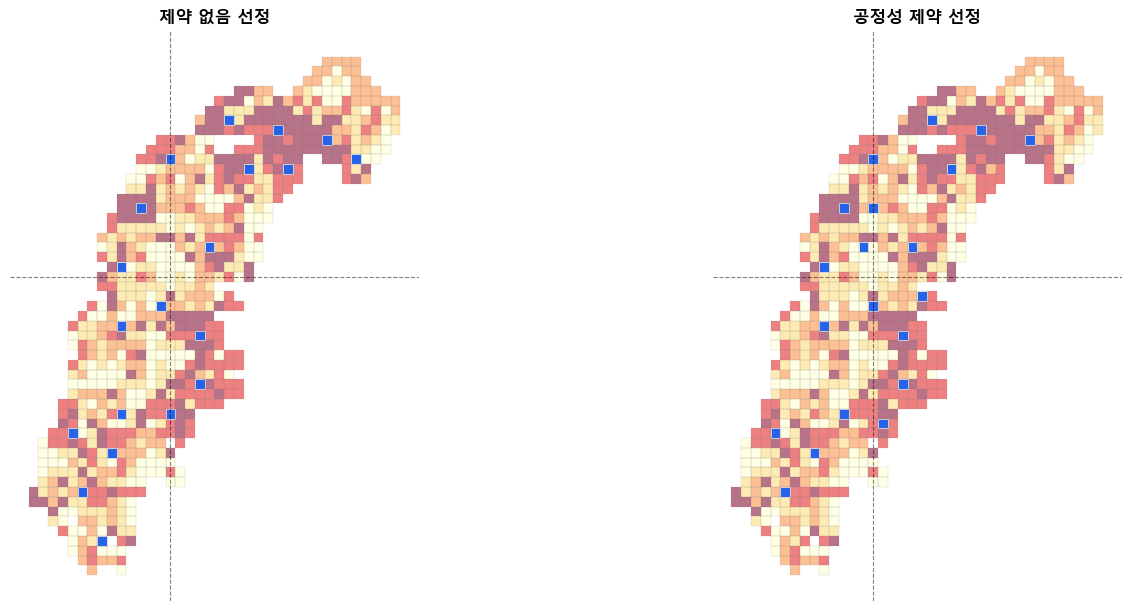

In [27]:
# Fairness map comparison
sel_u_gdf = cand_df.iloc[sel_u].copy() if len(sel_u) else cand_df.iloc[[]].copy()
sel_f_gdf = cand_df.iloc[sel_f].copy() if len(sel_f) else cand_df.iloc[[]].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

for ax, title, sub in [
    (axes[0], '\uc81c\uc57d \uc5c6\uc74c \uc120\uc815', sel_u_gdf),
    (axes[1], '\uacf5\uc815\uc131 \uc81c\uc57d \uc120\uc815', sel_f_gdf),
]:
    plot_base = gdf_m.copy()
    plot_base['w_q'] = pd.qcut(plot_base['demand_weight'].rank(method='first'), q=5, labels=False, duplicates='drop')
    plot_base.plot(column='w_q', cmap='YlOrRd', linewidth=0.05, edgecolor='none', ax=ax, alpha=0.55)
    gdf_m.boundary.plot(ax=ax, linewidth=0.2, color='gray', alpha=0.5)
    if len(sub):
        sub.plot(ax=ax, color='#2563eb', markersize=26, marker='o', edgecolor='white', linewidth=0.5)

    # quadrant guide lines
    ax.axvline(x=x_med, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axhline(y=y_med, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_axis_off()

plt.show()


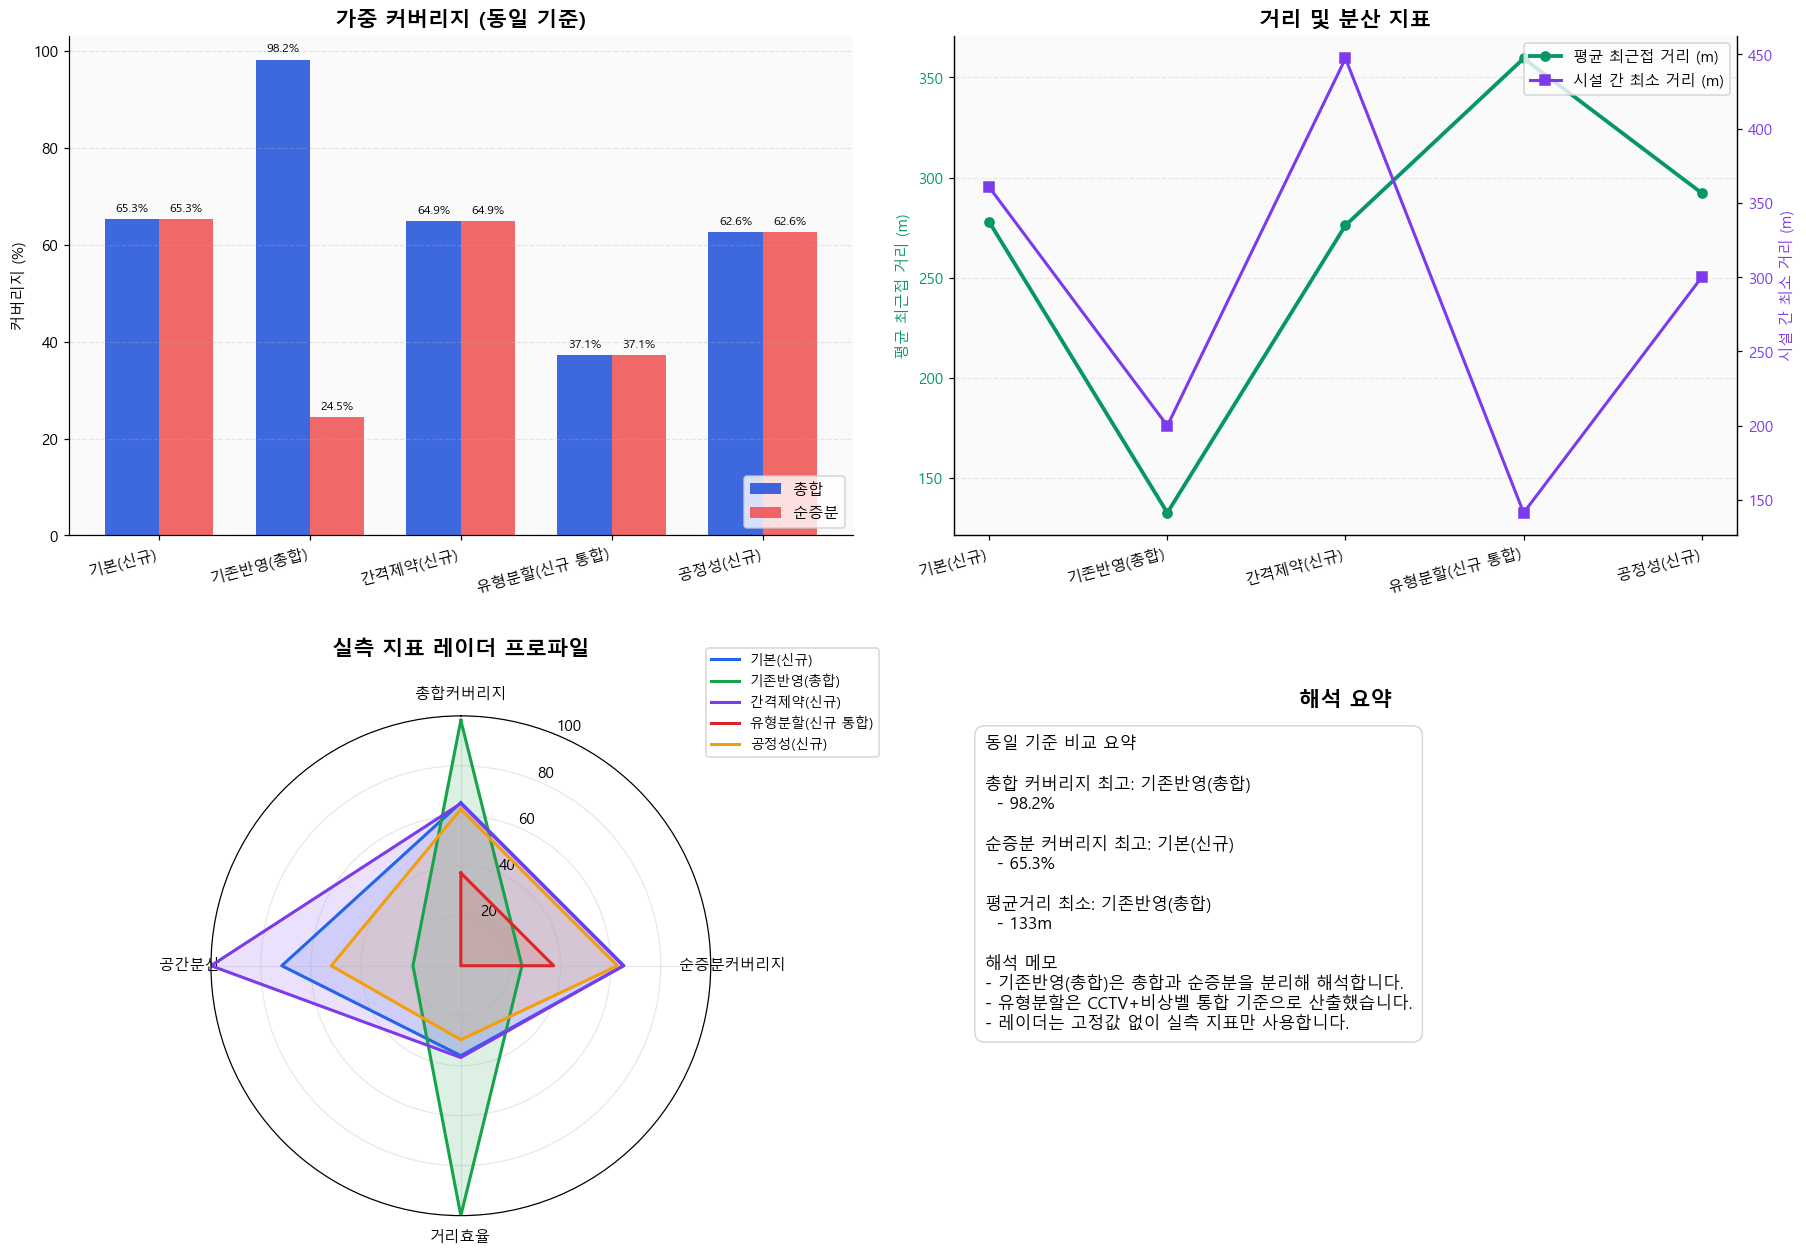

In [28]:
# Final integrated scenario visualization (harmonized metrics only)
if 'scenario_compare_df' not in locals() or not isinstance(scenario_compare_df, pd.DataFrame) or len(scenario_compare_df) == 0:
    raise RuntimeError('scenario_compare_df is not available. Run previous cells first.')

plot_df = scenario_compare_df.copy().reset_index(drop=True)
labels = plot_df['scenario_label'].tolist()

fig = plt.figure(figsize=(17, 12), dpi=110)
fig.patch.set_facecolor('#ffffff')

ax1 = plt.subplot(2, 2, 1)
ax2 = plt.subplot(2, 2, 2)
ax3 = plt.subplot(2, 2, 3, projection='polar')
ax4 = plt.subplot(2, 2, 4)
ax4.axis('off')

colors = ['#2563eb', '#16a34a', '#7c3aed', '#dc2626', '#f59e0b']
x = np.arange(len(plot_df))

# (1) Weighted coverage: total vs incremental
ax1.set_facecolor('#fafafa')
width = 0.36
bars_t = ax1.bar(x - width/2, plot_df['weighted_total_pct'], width,
                 color='#1d4ed8', alpha=0.85, label='\ucd1d\ud569')
bars_i = ax1.bar(x + width/2, plot_df['weighted_increment_pct'], width,
                 color='#ef4444', alpha=0.80, label='\uc21c\uc99d\ubd84')

for bars in [bars_t, bars_i]:
    for b in bars:
        h = b.get_height()
        if np.isfinite(h):
            ax1.annotate(f'{h:.1f}%',
                         xy=(b.get_x() + b.get_width()/2, h),
                         xytext=(0, 3), textcoords='offset points',
                         ha='center', va='bottom', fontsize=8)

ax1.set_title('\uac00\uc911 \ucee4\ubc84\ub9ac\uc9c0 (\ub3d9\uc77c \uae30\uc900)', fontsize=14, fontweight='bold')
ax1.set_ylabel('\ucee4\ubc84\ub9ac\uc9c0 (%)')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=15, ha='right')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.legend(loc='lower right', frameon=True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# (2) Distance and spacing quality
ax2.set_facecolor('#fafafa')
line1 = ax2.plot(x, plot_df['mean_nearest_distance_m'], color='#059669', marker='o', linewidth=2.5, label='\ud3c9\uade0 \ucd5c\uadfc\uc811 \uac70\ub9ac (m)')
ax2.set_ylabel('\ud3c9\uade0 \ucd5c\uadfc\uc811 \uac70\ub9ac (m)', color='#059669')
ax2.tick_params(axis='y', labelcolor='#059669')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=15, ha='right')
ax2.grid(axis='y', alpha=0.25, linestyle='--')
ax2.spines['top'].set_visible(False)

ax2b = ax2.twinx()
line2 = ax2b.plot(x, plot_df['min_pair_distance_m'], color='#7c3aed', marker='s', linewidth=2.0, label='\uc2dc\uc124 \uac04 \ucd5c\uc18c \uac70\ub9ac (m)')
ax2b.set_ylabel('\uc2dc\uc124 \uac04 \ucd5c\uc18c \uac70\ub9ac (m)', color='#7c3aed')
ax2b.tick_params(axis='y', labelcolor='#7c3aed')
ax2b.spines['top'].set_visible(False)

all_lines = line1 + line2
ax2.legend(all_lines, [l.get_label() for l in all_lines], loc='upper right', frameon=True)
ax2.set_title('\uac70\ub9ac \ubc0f \ubd84\uc0b0 \uc9c0\ud45c', fontsize=14, fontweight='bold')

# (3) Radar with measured metrics only
metrics = ['\ucd1d\ud569\ucee4\ubc84\ub9ac\uc9c0', '\uc21c\uc99d\ubd84\ucee4\ubc84\ub9ac\uc9c0', '\uac70\ub9ac\ud6a8\uc728', '\uacf5\uac04\ubd84\uc0b0']
angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

# distance efficiency: lower distance => higher score
dist = plot_df['mean_nearest_distance_m'].to_numpy(dtype=float)
if np.isfinite(dist).any() and (np.nanmax(dist) > np.nanmin(dist)):
    dist_eff = (np.nanmax(dist) - dist) / (np.nanmax(dist) - np.nanmin(dist)) * 100.0
else:
    dist_eff = np.full(len(dist), 50.0)

# spacing spread score from min pair distance
spread = plot_df['min_pair_distance_m'].to_numpy(dtype=float)
if np.isfinite(spread).any() and (np.nanmax(spread) > np.nanmin(spread)):
    spread_score = (spread - np.nanmin(spread)) / (np.nanmax(spread) - np.nanmin(spread)) * 100.0
else:
    spread_score = np.full(len(spread), 50.0)

radar_mat = np.column_stack([
    plot_df['weighted_total_pct'].to_numpy(dtype=float),
    plot_df['weighted_increment_pct'].to_numpy(dtype=float),
    dist_eff,
    spread_score,
])

for i, row in enumerate(radar_mat):
    vals = row.tolist() + [row[0]]
    ax3.plot(angles, vals, color=colors[i % len(colors)], linewidth=2.0, label=labels[i])
    ax3.fill(angles, vals, color=colors[i % len(colors)], alpha=0.15)

ax3.set_theta_offset(np.pi / 2)
ax3.set_theta_direction(-1)
ax3.set_thetagrids(np.degrees(angles[:-1]), metrics)
ax3.set_ylim(0, 100)
ax3.grid(alpha=0.3)
ax3.set_title('\uc2e4\uce21 \uc9c0\ud45c \ub808\uc774\ub354 \ud504\ub85c\ud30c\uc77c', fontsize=14, fontweight='bold', pad=20)
ax3.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)

# (4) Data-driven text summary
best_total_idx = int(np.nanargmax(plot_df['weighted_total_pct'].to_numpy(dtype=float)))
best_incr_idx = int(np.nanargmax(plot_df['weighted_increment_pct'].to_numpy(dtype=float)))
best_dist_idx = int(np.nanargmin(plot_df['mean_nearest_distance_m'].to_numpy(dtype=float)))

summary_text = (
    '\ub3d9\uc77c \uae30\uc900 \ube44\uad50 \uc694\uc57d\n\n'
    f"\ucd1d\ud569 \ucee4\ubc84\ub9ac\uc9c0 \ucd5c\uace0: {labels[best_total_idx]}\n"
    f"  - {plot_df.loc[best_total_idx, 'weighted_total_pct']:.1f}%\n\n"
    f"\uc21c\uc99d\ubd84 \ucee4\ubc84\ub9ac\uc9c0 \ucd5c\uace0: {labels[best_incr_idx]}\n"
    f"  - {plot_df.loc[best_incr_idx, 'weighted_increment_pct']:.1f}%\n\n"
    f"\ud3c9\uade0\uac70\ub9ac \ucd5c\uc18c: {labels[best_dist_idx]}\n"
    f"  - {plot_df.loc[best_dist_idx, 'mean_nearest_distance_m']:.0f}m\n\n"
    '\ud574\uc11d \uba54\ubaa8\n'
    '- \uae30\uc874\ubc18\uc601(\ucd1d\ud569)\uc740 \ucd1d\ud569\uacfc \uc21c\uc99d\ubd84\uc744 \ubd84\ub9ac\ud574 \ud574\uc11d\ud569\ub2c8\ub2e4.\n'
    '- \uc720\ud615\ubd84\ud560\uc740 CCTV+\ube44\uc0c1\ubca8 \ud1b5\ud569 \uae30\uc900\uc73c\ub85c \uc0b0\ucd9c\ud588\uc2b5\ub2c8\ub2e4.\n'
    '- \ub808\uc774\ub354\ub294 \uace0\uc815\uac12 \uc5c6\uc774 \uc2e4\uce21 \uc9c0\ud45c\ub9cc \uc0ac\uc6a9\ud569\ub2c8\ub2e4.'
)

ax4.text(
    0.04, 0.96, summary_text,
    transform=ax4.transAxes,
    va='top',
    fontsize=11,
    bbox=dict(boxstyle='round,pad=0.6', facecolor='white', edgecolor='#d1d5db', alpha=0.95),
)
ax4.set_title('\ud574\uc11d \uc694\uc57d', fontsize=14, fontweight='bold')

plt.tight_layout(pad=2.8)
plt.show()


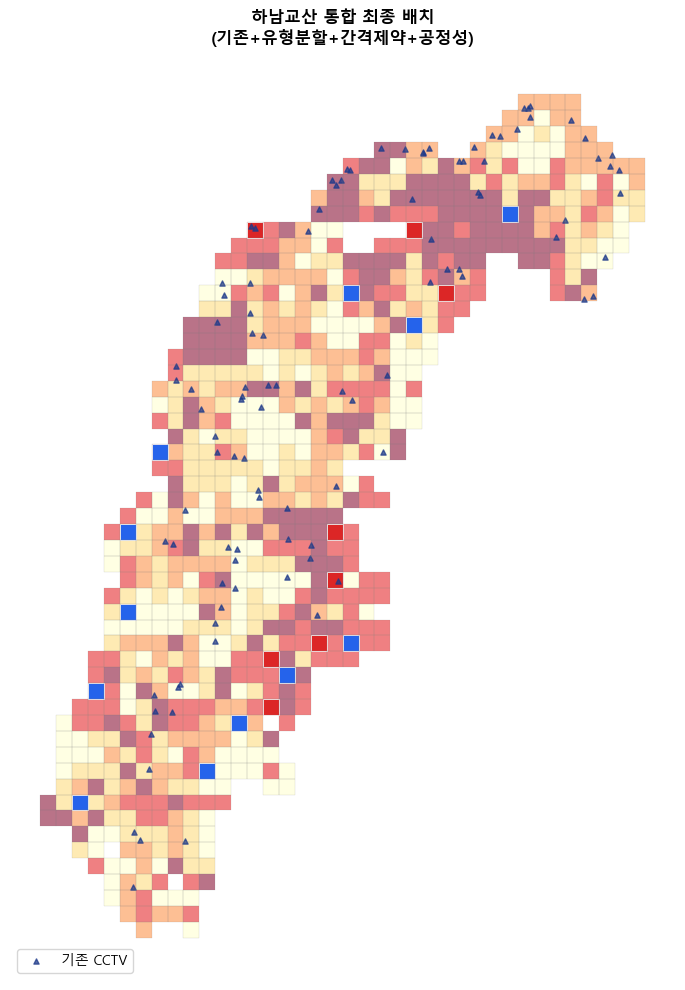

advanced outputs saved:
- C:\Users\a0109\.jupyter\1최종_LH\data\통합_데이터\hanam_gyosan_sensitivity_analysis.csv | exists = True
- C:\Users\a0109\.jupyter\1최종_LH\data\통합_데이터\hanam_gyosan_spacing_analysis.csv | exists = True
- C:\Users\a0109\.jupyter\1최종_LH\data\통합_데이터\hanam_gyosan_existing_reflection_analysis.csv | exists = True
- C:\Users\a0109\.jupyter\1최종_LH\data\통합_데이터\hanam_gyosan_facility_split_summary.csv | exists = True
- C:\Users\a0109\.jupyter\1최종_LH\data\통합_데이터\hanam_gyosan_facility_split_selected.csv | exists = True
- C:\Users\a0109\.jupyter\1최종_LH\data\통합_데이터\hanam_gyosan_facility_split_selected.geojson | exists = True
- C:\Users\a0109\.jupyter\1최종_LH\data\통합_데이터\hanam_gyosan_fairness_compare.csv | exists = True
- C:\Users\a0109\.jupyter\1최종_LH\data\통합_데이터\hanam_gyosan_combined_summary.csv | exists = True
- C:\Users\a0109\.jupyter\1최종_LH\data\통합_데이터\hanam_gyosan_combined_selected.csv | exists = True
- C:\Users\a0109\.jupyter\1최종_LH\data\통합_데이터\hanam_gyosan_combined_selected.geoj

In [29]:
# Combined final map + exports
if 'facility_cfg' not in locals():
    facility_cfg = {
        'CCTV': {'color': '#2563eb', 'radius_m': 250.0},
        'EmergencyBell': {'color': '#dc2626', 'radius_m': 150.0},
    }
if 'combined_selected_gdf' not in locals():
    if 'facility_selected_gdf' in locals():
        combined_selected_gdf = facility_selected_gdf.copy()
    else:
        combined_selected_gdf = gpd.GeoDataFrame(pd.DataFrame(columns=['facility']), geometry=[], crs=gdf_m.crs)
if 'combined_summary_df' not in locals():
    if 'facility_summary_df' in locals():
        combined_summary_df = facility_summary_df.copy()
    else:
        combined_summary_df = pd.DataFrame()
if 'fairness_compare_df' not in locals():
    fairness_compare_df = pd.DataFrame()

combined_map_png = output_dir / 'hanam_gyosan_combined_final_plan.png'

fig, ax = plt.subplots(figsize=(10, 10))
plot_base = gdf_m.copy()
plot_base['w_q'] = pd.qcut(plot_base['demand_weight'].rank(method='first'), q=5, labels=False, duplicates='drop')
plot_base.plot(column='w_q', cmap='YlOrRd', linewidth=0.05, edgecolor='none', ax=ax, alpha=0.55)
gdf_m.boundary.plot(ax=ax, linewidth=0.2, color='gray', alpha=0.5)

for fac_name, cfg in facility_cfg.items():
    if len(combined_selected_gdf):
        sub = combined_selected_gdf[combined_selected_gdf['facility'] == fac_name]
    else:
        sub = combined_selected_gdf
    if len(sub):
        sub.plot(ax=ax, color=cfg.get('color', '#2563eb'), markersize=32, marker='o', edgecolor='white', linewidth=0.6, label=f'\uc2e0\uaddc {fac_name}')

if 'existing_cctv' in locals() and len(existing_cctv):
    existing_cctv.plot(ax=ax, color='#1e3a8a', markersize=14, marker='^', alpha=0.75, label='\uae30\uc874 CCTV')
if 'existing_bell' in locals() and len(existing_bell):
    existing_bell.plot(ax=ax, color='#7f1d1d', markersize=14, marker='^', alpha=0.75, label='\uae30\uc874 \ube44\uc0c1\ubca8')

ax.set_title("\ud558\ub0a8\uad50\uc0b0 \ud1b5\ud569 \ucd5c\uc885 \ubc30\uce58\n(\uae30\uc874+\uc720\ud615\ubd84\ud560+\uac04\uaca9\uc81c\uc57d+\uacf5\uc815\uc131)", fontsize=12, fontweight='bold')
ax.set_axis_off()
handles, labels = ax.get_legend_handles_labels()
if len(handles):
    ax.legend(loc='lower left', frameon=True)
plt.tight_layout()
fig.savefig(combined_map_png, dpi=230, bbox_inches='tight')
plt.show()

# --- Union KPI: existing + new combined union coverage ---
def _union_cover_by_points(demand_xy, points_gdf, radius_m):
    if points_gdf is None or len(points_gdf) == 0:
        return np.zeros(len(demand_xy), dtype=bool)
    geom = points_gdf.geometry
    geom = geom[geom.notna() & geom.is_valid]
    if len(geom) == 0:
        return np.zeros(len(demand_xy), dtype=bool)
    # Use centroid so polygon/line inputs from grid selections are also supported.
    pts = geom.centroid
    pxy = np.column_stack([pts.x.values, pts.y.values])
    d2 = ((demand_xy[:, None, :] - pxy[None, :, :]) ** 2).sum(axis=2)
    return (d2 <= (radius_m ** 2)).any(axis=1)

union_existing = np.zeros(len(demand_xy_adv), dtype=bool)
if 'existing_cctv' in locals() and len(existing_cctv):
    union_existing |= _union_cover_by_points(demand_xy_adv, existing_cctv, facility_cfg.get('CCTV', {}).get('radius_m', 250.0))
if 'existing_bell' in locals() and len(existing_bell):
    union_existing |= _union_cover_by_points(demand_xy_adv, existing_bell, facility_cfg.get('EmergencyBell', {}).get('radius_m', 150.0))

union_new = np.zeros(len(demand_xy_adv), dtype=bool)
if len(combined_selected_gdf):
    for fac_name, cfg in facility_cfg.items():
        sub = combined_selected_gdf[combined_selected_gdf['facility'] == fac_name]
        union_new |= _union_cover_by_points(demand_xy_adv, sub, cfg.get('radius_m', 250.0))

union_total = union_existing | union_new

combined_union_kpi_df = pd.DataFrame([
    {
        'scenario': 'combined_union_total',
        'existing_coverage_ratio': float(union_existing.mean()),
        'new_coverage_ratio': float(union_new.mean()),
        'total_union_coverage_ratio': float(union_total.mean()),
        'total_union_weighted_coverage_ratio': float(base_weights[union_total].sum() / (base_weights.sum() + 1e-9)),
        'new_selected_count': int(len(combined_selected_gdf)),
        'existing_count': int((len(existing_cctv) if 'existing_cctv' in locals() else 0) + (len(existing_bell) if 'existing_bell' in locals() else 0)),
    }
])

# Save advanced outputs
sensitivity_csv = output_dir / 'hanam_gyosan_sensitivity_analysis.csv'
spacing_csv = output_dir / 'hanam_gyosan_spacing_analysis.csv'
existing_csv = output_dir / 'hanam_gyosan_existing_reflection_analysis.csv'
facility_summary_csv = output_dir / 'hanam_gyosan_facility_split_summary.csv'
facility_selected_csv = output_dir / 'hanam_gyosan_facility_split_selected.csv'
facility_selected_geojson = output_dir / 'hanam_gyosan_facility_split_selected.geojson'
fairness_csv = output_dir / 'hanam_gyosan_fairness_compare.csv'
combined_summary_csv = output_dir / 'hanam_gyosan_combined_summary.csv'
combined_selected_csv = output_dir / 'hanam_gyosan_combined_selected.csv'
combined_selected_geojson = output_dir / 'hanam_gyosan_combined_selected.geojson'
combined_union_kpi_csv = output_dir / 'hanam_gyosan_combined_union_kpi.csv'
scenario_compare_csv = output_dir / 'hanam_gyosan_scenario_compare_harmonized.csv'

sensitivity_df.to_csv(sensitivity_csv, index=False, encoding='utf-8-sig')
spacing_df.to_csv(spacing_csv, index=False, encoding='utf-8-sig')
existing_effect_df.to_csv(existing_csv, index=False, encoding='utf-8-sig')

if 'facility_summary_df' in locals():
    facility_summary_df.to_csv(facility_summary_csv, index=False, encoding='utf-8-sig')
    if len(facility_selected_gdf):
        pd.DataFrame(facility_selected_gdf.drop(columns='geometry')).to_csv(facility_selected_csv, index=False, encoding='utf-8-sig')
        facility_selected_gdf.to_file(facility_selected_geojson, driver='GeoJSON')

if len(fairness_compare_df):
    fairness_compare_df.to_csv(fairness_csv, index=False, encoding='utf-8-sig')
if len(combined_summary_df):
    combined_summary_df.to_csv(combined_summary_csv, index=False, encoding='utf-8-sig')
if len(combined_selected_gdf):
    pd.DataFrame(combined_selected_gdf.drop(columns='geometry')).to_csv(combined_selected_csv, index=False, encoding='utf-8-sig')
    combined_selected_gdf.to_file(combined_selected_geojson, driver='GeoJSON')

combined_union_kpi_df.to_csv(combined_union_kpi_csv, index=False, encoding='utf-8-sig')
if 'scenario_compare_df' in locals() and len(scenario_compare_df):
    scenario_compare_df.to_csv(scenario_compare_csv, index=False, encoding='utf-8-sig')

print('advanced outputs saved:')
for p in [
    sensitivity_csv, spacing_csv, existing_csv,
    facility_summary_csv, facility_selected_csv, facility_selected_geojson,
    fairness_csv,
    combined_summary_csv, combined_selected_csv, combined_selected_geojson,
    combined_union_kpi_csv,
    scenario_compare_csv,
    combined_map_png,
]:
    print('-', p, '| exists =', p.exists())

print('\ncombined_union_kpi:')
print(combined_union_kpi_df.to_string(index=False))